Запустите, пожалуйста, раздел "Подготовка" и приступайте к выполнению заданий.

## Подготовка

### Импорт библиотек

In [ ]:
# Массивы и работа с данными
import numpy as np
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Загрузка из google облака
import gdown

# Работа с папками и файлами
import os
import time
import random
import math
import pickle

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

# Параметризация аудио
import librosa

# Разбиение на обучающую и проверочную выборку
from sklearn.model_selection import train_test_split

# Кодирование категориальных меток, нормирование числовых данных
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

%matplotlib inline

### Загрузка датасета и подготовка данных

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip', None, quiet=False)

# Загрузка подготовленных данных
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/audio_data_mean.pickle', None, quiet=True)

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip
To: /content/genres.zip
100%|██████████| 1.23G/1.23G [00:15<00:00, 78.9MB/s]


'audio_data_mean.pickle'

In [ ]:
# Распаковка архива
!unzip -qo genres.zip

# Проверка выгруженных папок
!ls genres

# Проверка содержимого одной папки
!ls genres/blues

blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock
blues.00000.au	blues.00020.au	blues.00040.au	blues.00060.au	blues.00080.au
blues.00001.au	blues.00021.au	blues.00041.au	blues.00061.au	blues.00081.au
blues.00002.au	blues.00022.au	blues.00042.au	blues.00062.au	blues.00082.au
blues.00003.au	blues.00023.au	blues.00043.au	blues.00063.au	blues.00083.au
blues.00004.au	blues.00024.au	blues.00044.au	blues.00064.au	blues.00084.au
blues.00005.au	blues.00025.au	blues.00045.au	blues.00065.au	blues.00085.au
blues.00006.au	blues.00026.au	blues.00046.au	blues.00066.au	blues.00086.au
blues.00007.au	blues.00027.au	blues.00047.au	blues.00067.au	blues.00087.au
blues.00008.au	blues.00028.au	blues.00048.au	blues.00068.au	blues.00088.au
blues.00009.au	blues.00029.au	blues.00049.au	blues.00069.au	blues.00089.au
blues.00010.au	blues.00030.au	blues.00050.au	blues.00070.au	blues.00090.au
blues.00011.au	blues.00031.au	blues.00051.au	blues.00071.au	blues.00091.au
blues.00012.au	blues.00032.a

In [ ]:
# Установка констант

FILE_DIR = './genres'                     # Папка с файлами датасета
CLASS_LIST = os.listdir(FILE_DIR)         # Список классов, порядок меток не определен!
CLASS_LIST.sort()                         # Сортировка списка классов для фиксации порядка меток
CLASS_COUNT = len(CLASS_LIST)             # Количество классов
CLASS_FILES = 100                         # Общее количество файлов в каждом классе
FILE_INDEX_TRAIN_SPLIT = 90               # Количество файлов каждого класса на основной набор
VALIDATION_SPLIT = 0.1                    # Доля проверочной выборки в основном наборе
DURATION_SEC = 30                         # Анализируемая длительность аудиосигнала
N_FFT = 8192                              # Размер окна преобразования Фурье для расчета спектра
HOP_LENGTH = 512                          # Объем данных для расчета одного набора признаков

# PyTorch устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

Используется устройство: cpu


In [ ]:
# Проверка списка классов
print(CLASS_LIST)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [ ]:
# Функция параметризации аудио

def get_features(y,                     # волновое представление сигнала
                 sr,                    # частота дискретизации сигнала y
                 n_fft=N_FFT,           # размер скользящего окна БПФ
                 hop_length=HOP_LENGTH  # шаг скользящего окна БПФ
                 ):
    # Вычисление различных параметров (признаков) аудио

    # Хромаграмма
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Мел-кепстральные коэффициенты
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Среднеквадратическая амплитуда
    rmse = librosa.feature.rms(y=y, hop_length=hop_length)
    # Спектральный центроид
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Ширина полосы частот
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Спектральный спад частоты
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Пересечения нуля
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop_length)

    # Сборка параметров в общий список:
    # На один файл один усредненный вектор признаков
    features = {'rmse': rmse.mean(axis=1, keepdims=True),
                'spct': spec_cent.mean(axis=1, keepdims=True),
                'spbw': spec_bw.mean(axis=1, keepdims=True),
                'roff': rolloff.mean(axis=1, keepdims=True),
                'zcr' : zcr.mean(axis=1, keepdims=True),
                'mfcc': mfcc.mean(axis=1, keepdims=True),
                'stft': chroma_stft.mean(axis=1, keepdims=True)}

    return features

In [ ]:
# Функция объединения признаков в набор векторов

def stack_features(feat):
    features = None
    for v in feat.values():
        features = np.vstack((features, v)) if features is not None else v
    return features.T

In [ ]:
# Функция формирования набора признаков и метки класса для аудиофайла

def get_feature_list_from_file(class_index, song_name, duration_sec):
    y, sr = librosa.load(song_name, mono=True, duration=duration_sec)
    features = get_features(y, sr)
    feature_set = stack_features(features)

    # Возвращаем индекс класса (не one-hot, преобразуем позже)
    y_label = class_index

    return feature_set, y_label

In [ ]:
# Функция формирования подвыборки признаков и меток класса для одного файла

def process_file(class_index, file_index, duration_sec):
    class_name = CLASS_LIST[class_index]
    song_name = f'{FILE_DIR}/{class_name}/{class_name}.{str(file_index).zfill(5)}.au'

    feature_set, y_label = get_feature_list_from_file(class_index, song_name, duration_sec)

    # Усредняем по времени (один вектор на файл)
    feature_mean = np.mean(feature_set, axis=0, keepdims=True)

    return song_name, feature_mean.astype('float32'), y_label

In [ ]:
# Функция формирования набора данных из файлов всех классов по диапазону номеров файлов

def extract_data(file_index_start, file_index_end, duration_sec=DURATION_SEC):
    x_data = None
    y_data = None

    curr_time = time.time()

    for class_index in range(len(CLASS_LIST)):
        for file_index in range(file_index_start, file_index_end):
            _, file_x_data, file_y_data = process_file(class_index, file_index, duration_sec)
            x_data = file_x_data if x_data is None else np.vstack([x_data, file_x_data])
            y_data = np.append(y_data, file_y_data) if y_data is not None else np.array([file_y_data])

        print(f'Жанр {CLASS_LIST[class_index]} готов -> {round(time.time() - curr_time)} c')
        curr_time = time.time()

    return x_data, y_data

In [ ]:
x_train_data, y_train_data = extract_data(file_index_start=0,
                                          file_index_end=FILE_INDEX_TRAIN_SPLIT,
                                          duration_sec=DURATION_SEC)

print('Форма x_train_data:', x_train_data.shape)
print('Форма y_train_data:', y_train_data.shape)

# Приводим метки к int64 для PyTorch
y_train_data = y_train_data.astype(np.int64)

Жанр blues готов -> 137 c
Жанр classical готов -> 130 c
Жанр country готов -> 127 c
Жанр disco готов -> 137 c
Жанр hiphop готов -> 132 c
Жанр jazz готов -> 132 c
Жанр metal готов -> 132 c
Жанр pop готов -> 139 c
Жанр reggae готов -> 132 c
Жанр rock готов -> 132 c
Форма x_train_data: (900, 37)
Форма y_train_data: (900,)


In [ ]:
# Нормирование признаков в соответствии со стандартным нормальным распределением

x_scaler = StandardScaler()
x_train_data_scaled = x_scaler.fit_transform(x_train_data)

In [ ]:
# Разделение набора данных на обучающую и проверочную выборки
# Параметр stratify указывает метки классов, по которым происходит балансировка разделения

x_train, x_val, y_train, y_val = train_test_split(x_train_data_scaled,
                                                  y_train_data,  # вместо y_train_data_onehot
                                                  stratify=y_train_data,
                                                  test_size=VALIDATION_SPLIT)

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_val: {x_val.shape}, y_val: {y_val.shape}")

# Преобразование в тензоры PyTorch
x_train_tensor = torch.FloatTensor(x_train)
y_train_tensor = torch.LongTensor(y_train)  # LongTensor для меток (int64)
x_val_tensor = torch.FloatTensor(x_val)
y_val_tensor = torch.LongTensor(y_val)      # LongTensor для меток

# Создание DataLoader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

x_train: (810, 37), y_train: (810,)
x_val: (90, 37), y_val: (90,)


### Функция вывода графиков точности и ошибки по эпохам обучения

In [29]:
# Вывод графиков точности и ошибки распознавания на обучающей и проверочной выборках

def show_history(train_losses, val_losses, train_accs, val_accs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle('График процесса обучения модели')

    ax1.plot(train_accs, label='Доля верных ответов на обучающем наборе')
    ax1.plot(val_accs, label='Доля верных ответов на проверочном наборе')
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(train_losses, label='Ошибка на обучающем наборе')
    ax2.plot(val_losses, label='Ошибка на проверочном наборе')
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()

### Функции визуализации распознавания отдельных звуковых файлов

In [30]:
# Классификация файла и визуализация предсказания модели для него

def classify_file(model, x_scaler, class_index, file_index):
    model.eval()

    song_name, file_x_data, file_y_data = process_file(class_index, file_index, DURATION_SEC)
    file_x_data = x_scaler.transform(file_x_data)

    print('Файл:', song_name)
    print('Вектор для предсказания:', file_x_data.shape)

    # Преобразование в тензор
    file_tensor = torch.FloatTensor(file_x_data).to(device)

    with torch.no_grad():
        predict = model(file_tensor)
        predict_mean = predict.cpu().numpy()[0]

    predict_class_index = np.argmax(predict_mean)
    predict_good = predict_class_index == class_index

    plt.figure(figsize=(10, 3))
    print('Классификация сети:', CLASS_LIST[predict_class_index], '-', 'ВЕРНО :-)' if predict_good else 'НЕВЕРНО.')
    plt.title('Среднее распределение векторов предсказаний')
    plt.bar(CLASS_LIST, predict_mean, color='g' if predict_good else 'r')
    plt.xticks(rotation=45)
    plt.show()
    print('---------------------------------------------------------------')

    return predict_class_index

In [31]:
# Классификация и визуализация нескольких файлов каждого класса

def classify_test_files(model, x_scaler, from_index, n_files):
    model.eval()
    predict_all = 0
    predict_good = 0
    y_true = []
    y_pred = []

    for class_index in range(CLASS_COUNT):
        for file_index in range(from_index, from_index + n_files):
            predict_class_index = classify_file(model, x_scaler, class_index, file_index)
            y_true.append(class_index)
            y_pred.append(predict_class_index)
            predict_all += 1
            predict_good += (predict_class_index == class_index)

    good_ratio = round(predict_good / predict_all * 100., 2)
    print(f'=== Обработано образцов: {predict_all}, из них распознано верно: {predict_good}, доля верных: {good_ratio}% ===')

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title('Матрица ошибок по файлам аудио (не нормализованная)')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
    disp.plot(ax=ax)
    plt.xticks(rotation=45)
    plt.show()

##Заданиe

В предыдущих ячейках были подготовлены все данные для обучения модели нейронной сети.
1. Проверьте форму данных обучающей и проверочной выборок (выведите на экран).

In [32]:
print(f"Форма обучающей выборки x_train: {x_train.shape}")
print(f"Форма обучающей выборки y_train: {y_train.shape}")
print(f"Форма проверочной выборки x_val: {x_val.shape}")
print(f"Форма проверочной выборки y_val: {y_val.shape}")
print(f"Количество классов: {CLASS_COUNT}")
print(f"Жанры: {CLASS_LIST}")

Форма обучающей выборки x_train: (810, 37)
Форма обучающей выборки y_train: (810,)
Форма проверочной выборки x_val: (90, 37)
Форма проверочной выборки y_val: (90,)
Количество классов: 10
Жанры: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


2. Составьте модель классификатора на полносвязных слоях и сохраните ее в переменной **model**. Для этого:
 - Используйте заготовку для последовательной модели **Sequential**;
 - Добавьте полносвязный слой на **64** нейрона с активационной функцией **'relu'**, после него добавьте слой **Dropout** с долей отключаемых нейронов **30%**;
 - Добавьте следующий полносвязный слой на **32** нейрона с активационной функцией **'relu'**, после него добавьте слой **Dropout** с долей отключаемых нейронов **30%**;
 - Добавьте следующий полносвязный слой на **16** нейронов с активационной функцией **'relu'**, после него добавьте слой **Dropout** с долей отключаемых нейронов **20%**;
 - Добавьте слой пакетной нормализации;
 - Добавьте финальный полносвязный слой классификатора на число нейронов по числу классов (**CLASS_COUNT**) с активационной функцией **'softmax'** .

In [33]:
class AudioClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(AudioClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, num_classes)
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.3)
        self.dropout3 = nn.Dropout(0.2)
        self.batchnorm = nn.BatchNorm1d(16)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        x = self.batchnorm(x)
        x = self.fc4(x)
        x = torch.softmax(x, dim=1)
        return x

model = AudioClassifier(x_train.shape[1], CLASS_COUNT).to(device)

3. Откомпилируйте созданную модель методом `.compile()` с указанием оптимизатора **Adam** и начальным шагом обучения **0.0001**, функцией ошибки **'categorical_crossentropy'** и метрикой **'accuracy'**;
Выведите на экран сводку архитектуры полученной модели методом `.summary()` .

In [34]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

print(model)

AudioClassifier(
  (fc1): Linear(in_features=37, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=10, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (dropout2): Dropout(p=0.3, inplace=False)
  (dropout3): Dropout(p=0.2, inplace=False)
  (batchnorm): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


4. Обучите модель и выведите графики обучения:
 - Обучите созданную и откомпилированную модель классификатора на данных обучающей выборки **x_train, y_train**, используя проверочные данные **x_val, y_val**, размер батча **32** и количество эпох **1000**. Результаты обучения сохраните в переменной **history** .
 - В разделе **"Функция вывода графиков точности и ошибки по эпохам обучения"** найдите определение функции `show_history()`, изучите требуемые параметры для нее и используйте для построения графиков точности и ошибки на протяжении эпох обучения.

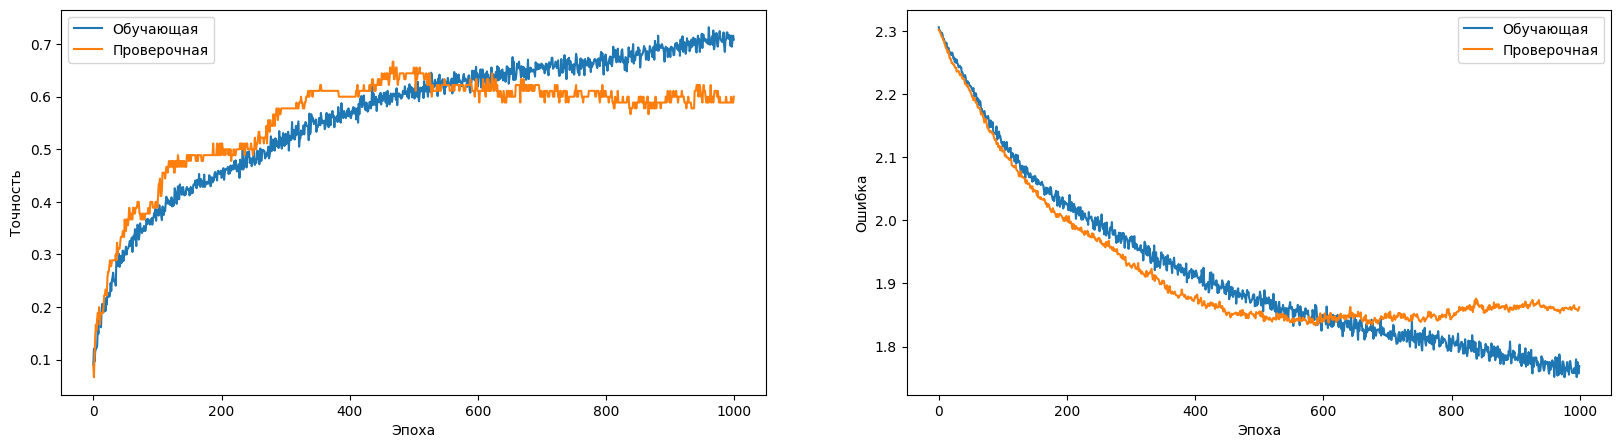


Финальная точность (обучение): 70.86%
Финальная точность (проверка): 60.00%


In [36]:
epochs = 1000
batch_size = 32

# DataLoader
train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(epochs):
    # Обучение
    model.train()
    train_loss, correct_train, total_train = 0, 0, 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

    # Валидация
    model.eval()
    val_loss, correct_val, total_val = 0, 0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()

    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    train_accs.append(correct_train / total_train)
    val_accs.append(correct_val / total_val)

# Графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
ax1.plot(train_accs, label='Обучающая')
ax1.plot(val_accs, label='Проверочная')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Точность')
ax1.legend()

ax2.plot(train_losses, label='Обучающая')
ax2.plot(val_losses, label='Проверочная')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Ошибка')
ax2.legend()
plt.show()

print(f"\nФинальная точность (обучение): {train_accs[-1]*100:.2f}%")
print(f"Финальная точность (проверка): {val_accs[-1]*100:.2f}%")

5. Проверьте работу модели:
 - В разделе **Функции визуализации распознавания отдельных звуковых файлов** найдите определение функции `classify_test_files()` и изучите ее параметры. Используйте функцию для визуализации работы классификатора на произвольном количестве тестовых звуковых файлов, полагая, что:
 - вы используете обученная в задании 4 модель классификатора аудио;
 - нормализатор **x_scaler** уже настроен ранее в ноутбуке, и его нужно передать в функцию `classify_test_files()` вместо параметра **x_scaler**;
 - тестовые звуковые файлы начинаются с индекса **90** и всего их ровно **10** для каждого класса.

Файл: ./genres/blues/blues.00090.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - ВЕРНО :-)


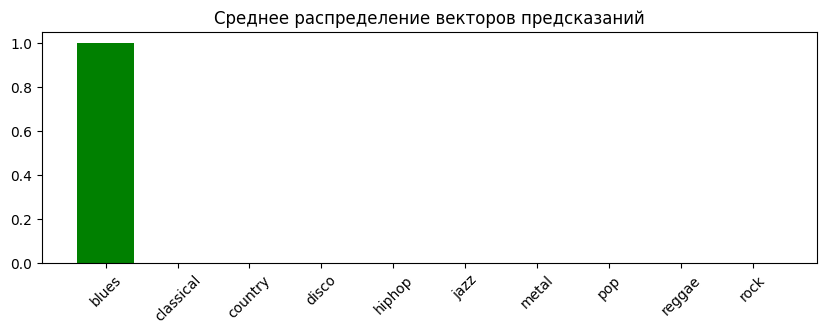

---------------------------------------------------------------
Файл: ./genres/blues/blues.00091.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - ВЕРНО :-)


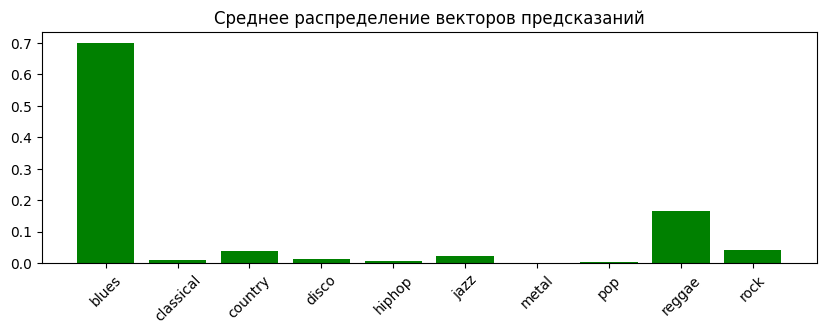

---------------------------------------------------------------
Файл: ./genres/blues/blues.00092.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - ВЕРНО :-)


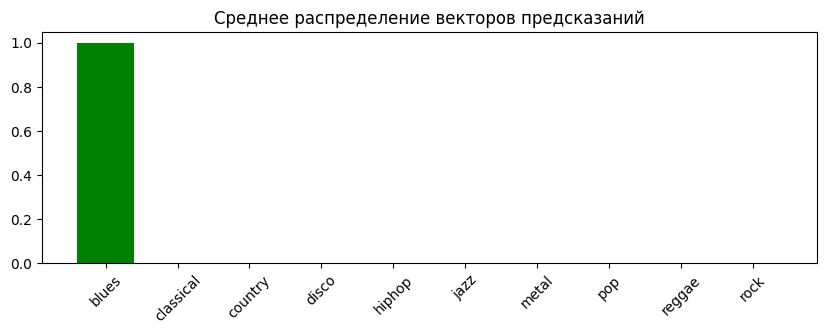

---------------------------------------------------------------
Файл: ./genres/blues/blues.00093.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - ВЕРНО :-)


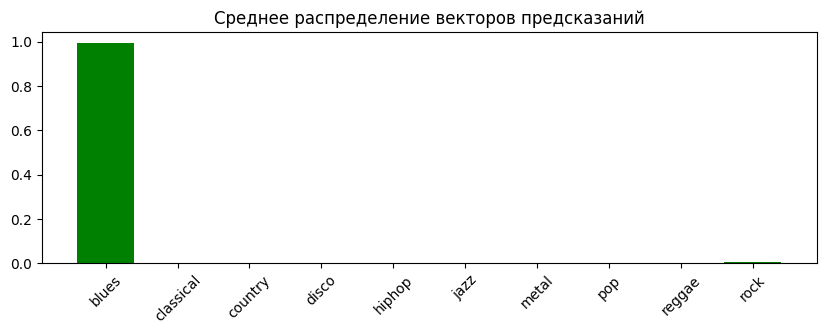

---------------------------------------------------------------
Файл: ./genres/blues/blues.00094.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - ВЕРНО :-)


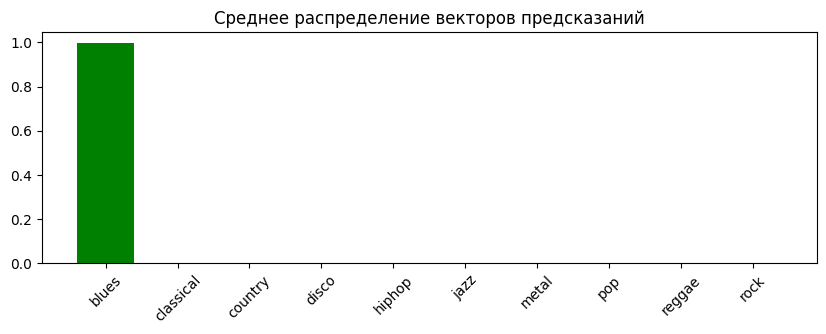

---------------------------------------------------------------
Файл: ./genres/blues/blues.00095.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - ВЕРНО :-)


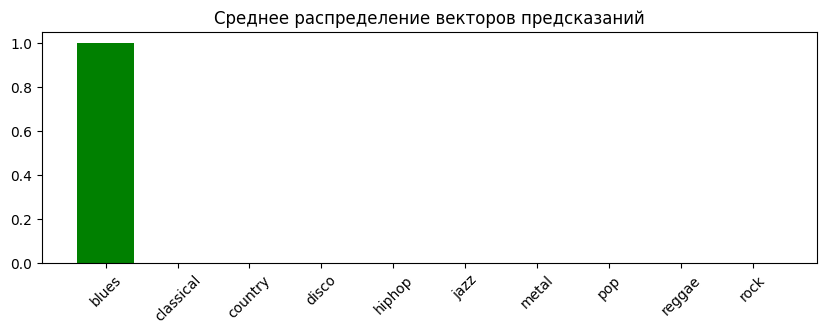

---------------------------------------------------------------
Файл: ./genres/blues/blues.00096.au
Вектор для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


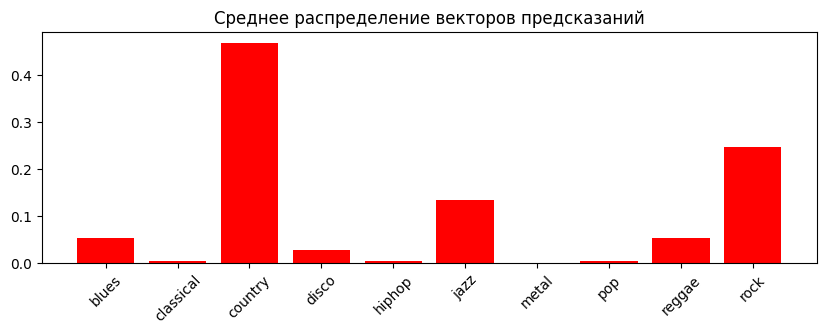

---------------------------------------------------------------
Файл: ./genres/blues/blues.00097.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - ВЕРНО :-)


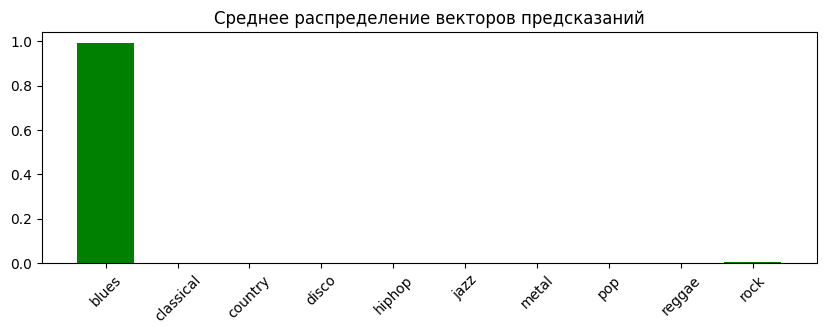

---------------------------------------------------------------
Файл: ./genres/blues/blues.00098.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


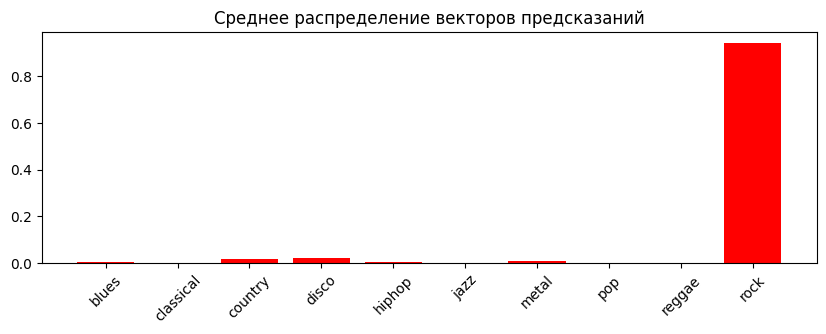

---------------------------------------------------------------
Файл: ./genres/blues/blues.00099.au
Вектор для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


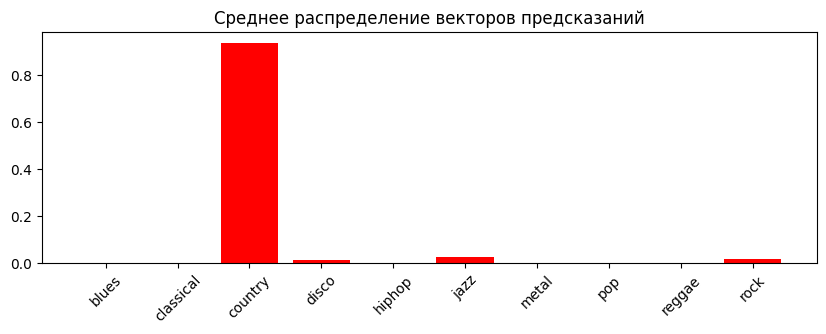

---------------------------------------------------------------
Файл: ./genres/classical/classical.00090.au
Вектор для предсказания: (1, 37)
Классификация сети: classical - ВЕРНО :-)


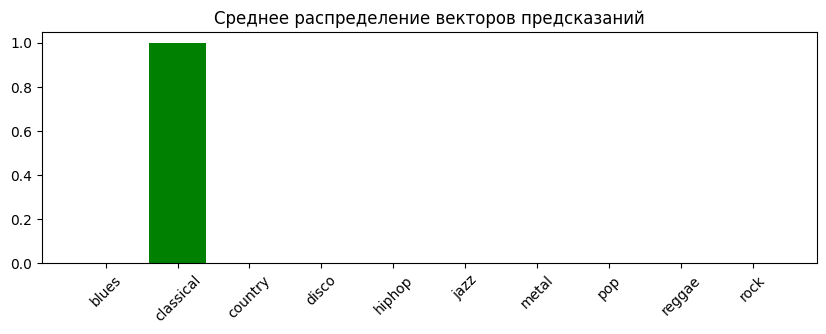

---------------------------------------------------------------
Файл: ./genres/classical/classical.00091.au
Вектор для предсказания: (1, 37)
Классификация сети: classical - ВЕРНО :-)


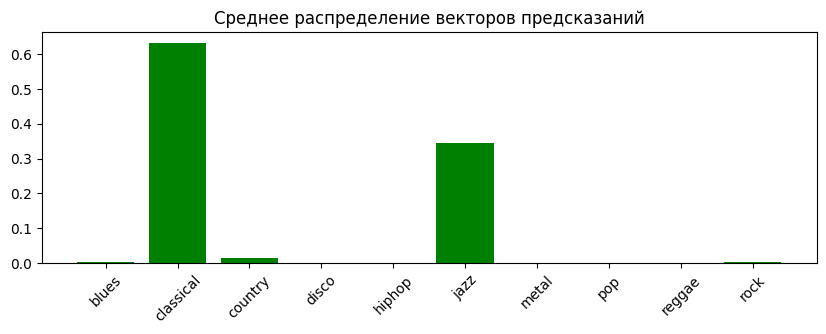

---------------------------------------------------------------
Файл: ./genres/classical/classical.00092.au
Вектор для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


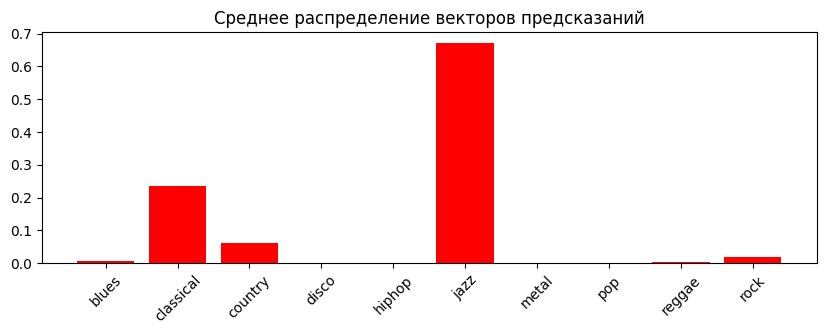

---------------------------------------------------------------
Файл: ./genres/classical/classical.00093.au
Вектор для предсказания: (1, 37)
Классификация сети: classical - ВЕРНО :-)


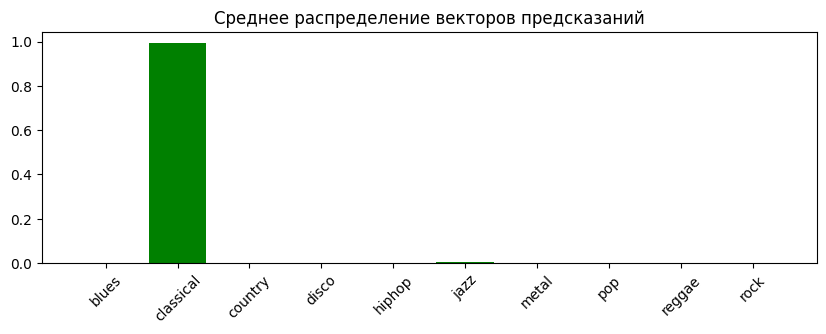

---------------------------------------------------------------
Файл: ./genres/classical/classical.00094.au
Вектор для предсказания: (1, 37)
Классификация сети: classical - ВЕРНО :-)


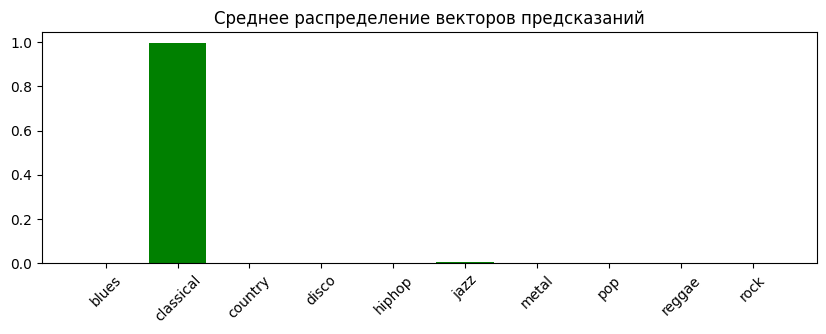

---------------------------------------------------------------
Файл: ./genres/classical/classical.00095.au
Вектор для предсказания: (1, 37)
Классификация сети: classical - ВЕРНО :-)


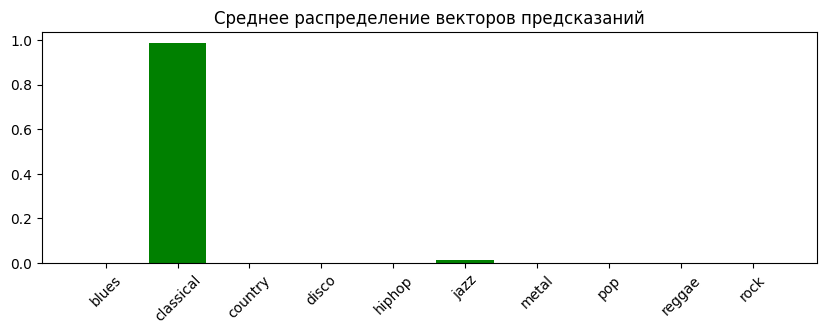

---------------------------------------------------------------
Файл: ./genres/classical/classical.00096.au
Вектор для предсказания: (1, 37)
Классификация сети: classical - ВЕРНО :-)


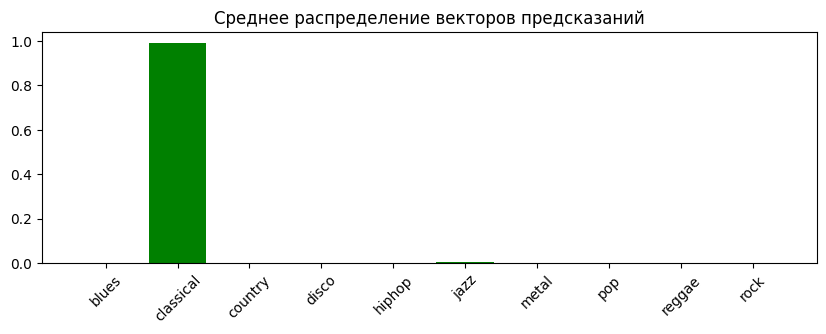

---------------------------------------------------------------
Файл: ./genres/classical/classical.00097.au
Вектор для предсказания: (1, 37)
Классификация сети: classical - ВЕРНО :-)


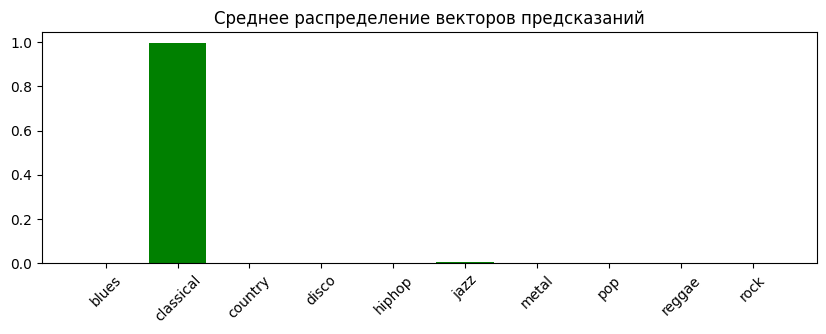

---------------------------------------------------------------
Файл: ./genres/classical/classical.00098.au
Вектор для предсказания: (1, 37)
Классификация сети: classical - ВЕРНО :-)


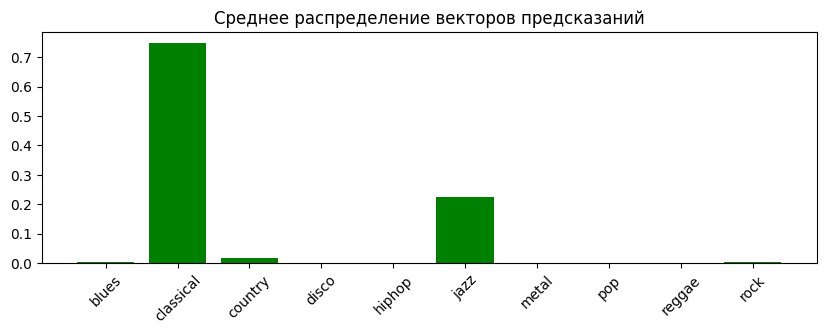

---------------------------------------------------------------
Файл: ./genres/classical/classical.00099.au
Вектор для предсказания: (1, 37)
Классификация сети: classical - ВЕРНО :-)


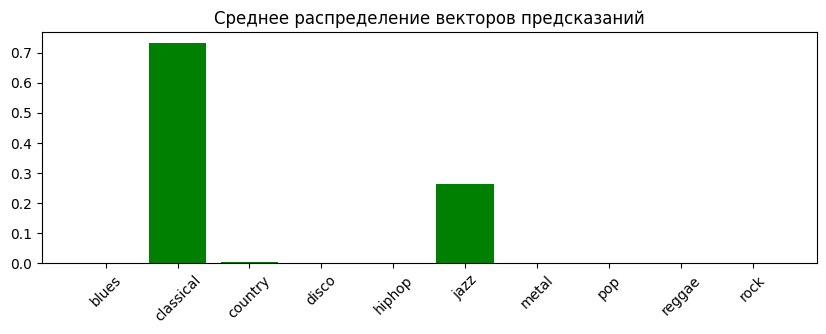

---------------------------------------------------------------
Файл: ./genres/country/country.00090.au
Вектор для предсказания: (1, 37)
Классификация сети: metal - НЕВЕРНО.


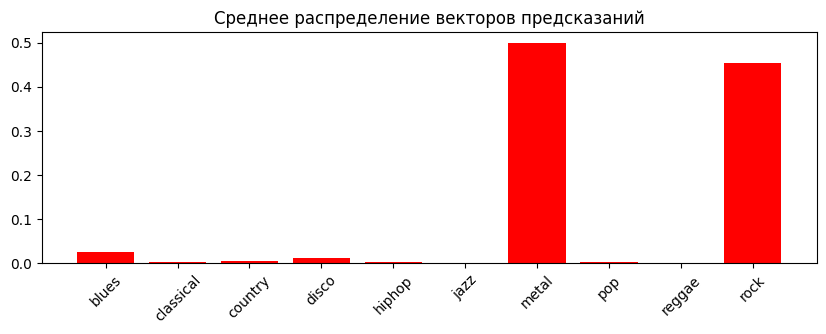

---------------------------------------------------------------
Файл: ./genres/country/country.00091.au
Вектор для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


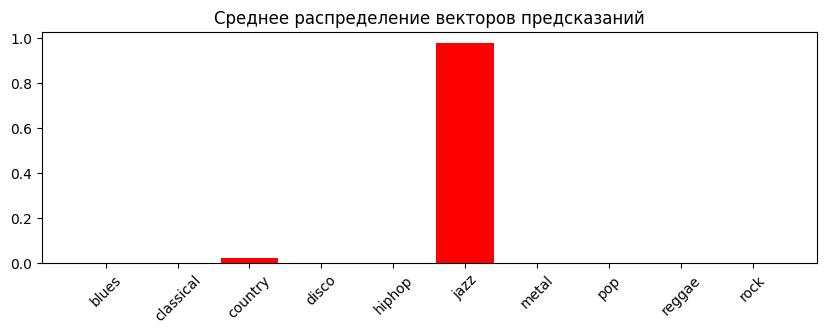

---------------------------------------------------------------
Файл: ./genres/country/country.00092.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


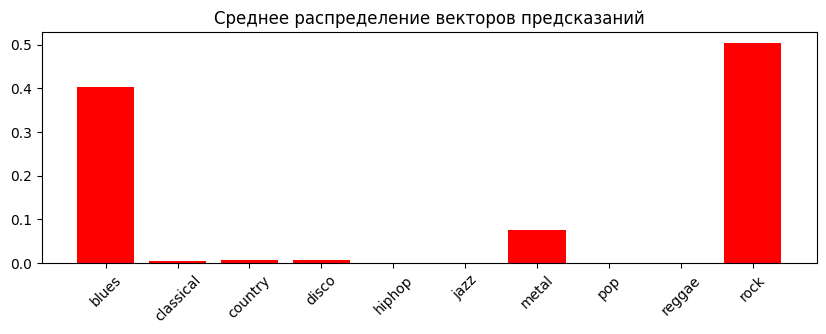

---------------------------------------------------------------
Файл: ./genres/country/country.00093.au
Вектор для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


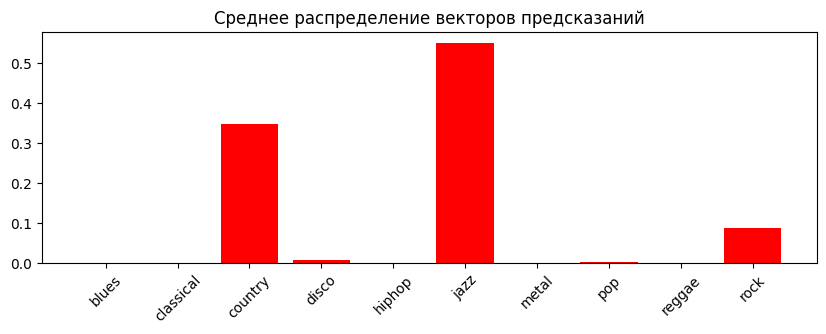

---------------------------------------------------------------
Файл: ./genres/country/country.00094.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


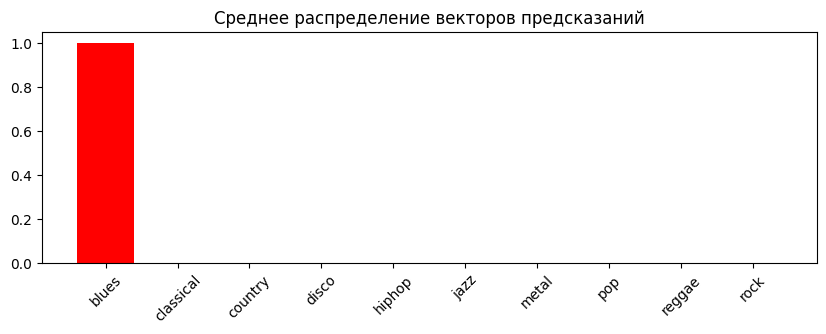

---------------------------------------------------------------
Файл: ./genres/country/country.00095.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


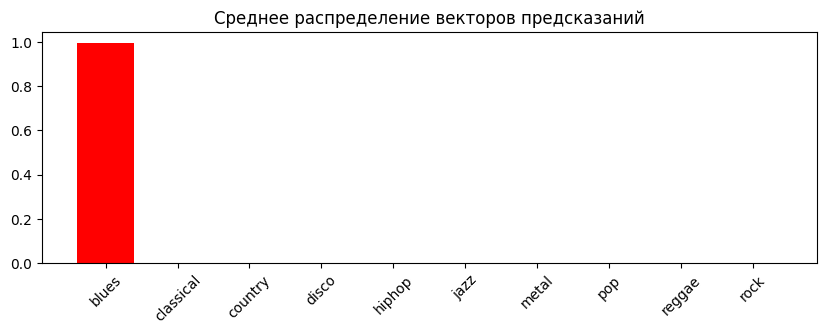

---------------------------------------------------------------
Файл: ./genres/country/country.00096.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


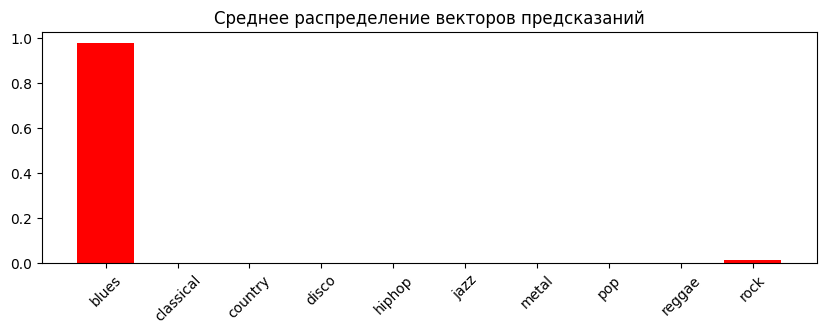

---------------------------------------------------------------
Файл: ./genres/country/country.00097.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


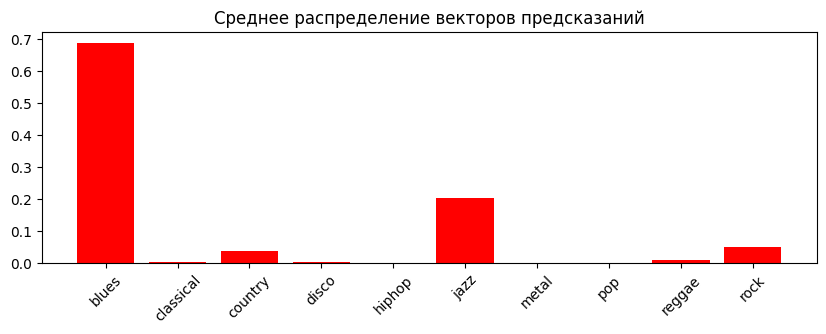

---------------------------------------------------------------
Файл: ./genres/country/country.00098.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


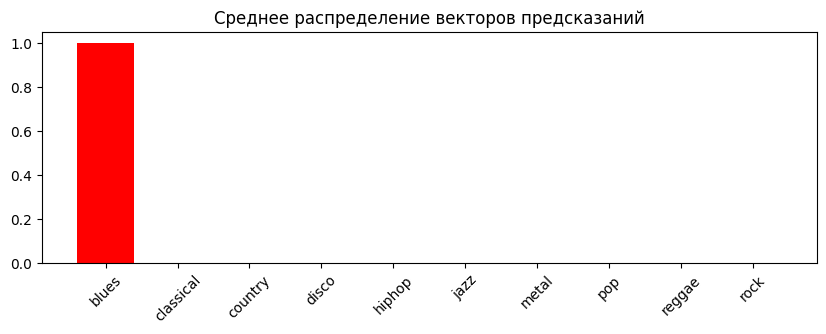

---------------------------------------------------------------
Файл: ./genres/country/country.00099.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


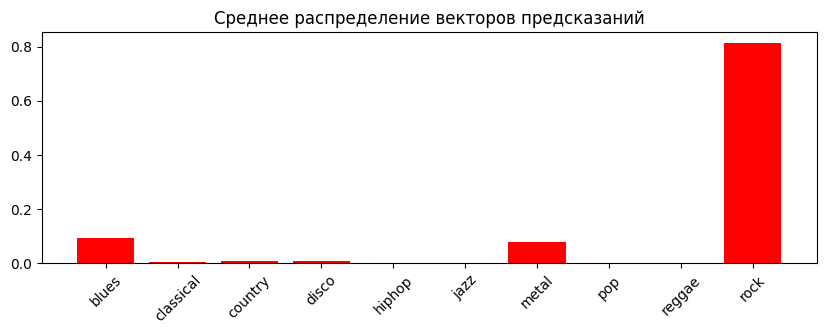

---------------------------------------------------------------
Файл: ./genres/disco/disco.00090.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


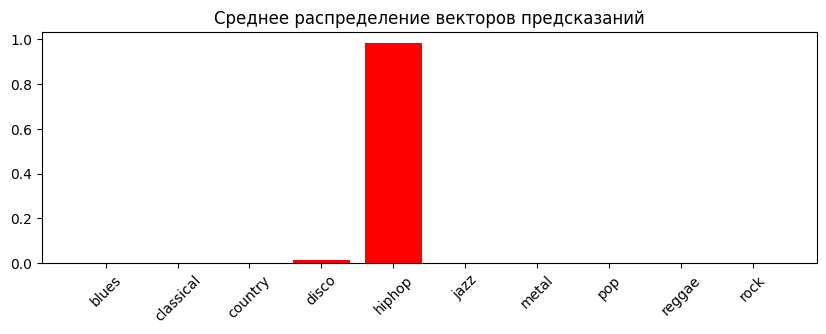

---------------------------------------------------------------
Файл: ./genres/disco/disco.00091.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


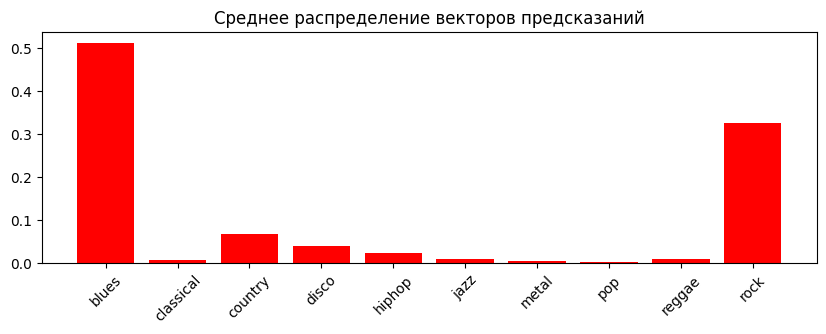

---------------------------------------------------------------
Файл: ./genres/disco/disco.00092.au
Вектор для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


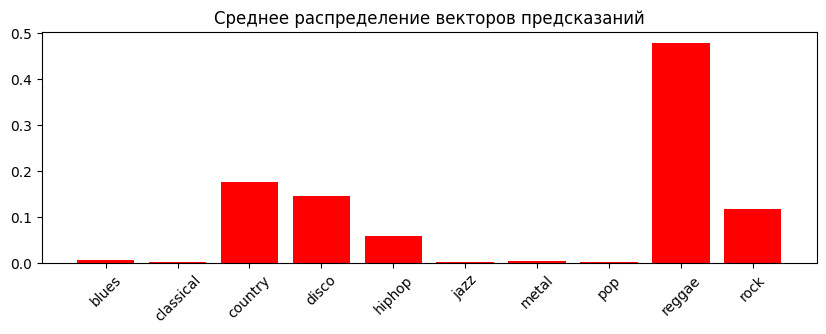

---------------------------------------------------------------
Файл: ./genres/disco/disco.00093.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


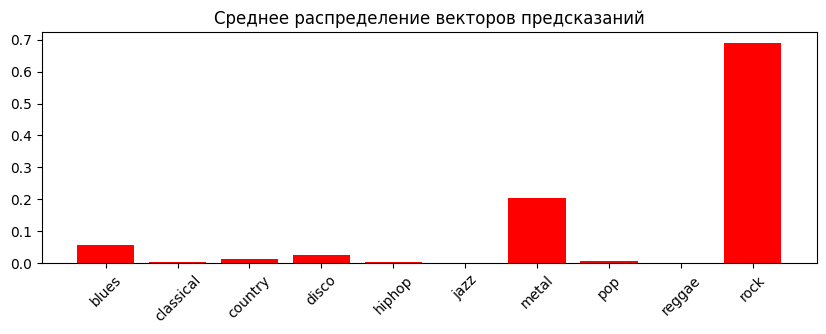

---------------------------------------------------------------
Файл: ./genres/disco/disco.00094.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


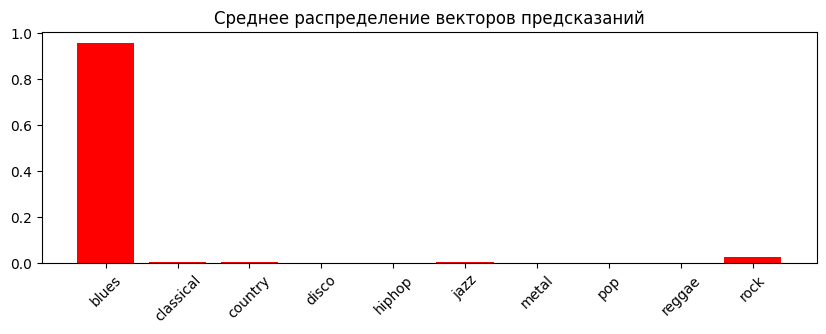

---------------------------------------------------------------
Файл: ./genres/disco/disco.00095.au
Вектор для предсказания: (1, 37)
Классификация сети: metal - НЕВЕРНО.


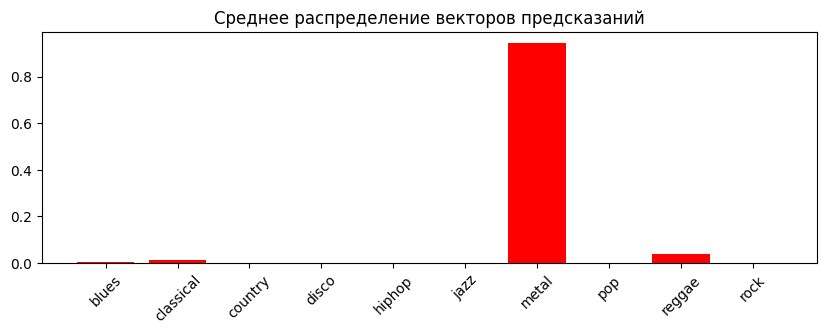

---------------------------------------------------------------
Файл: ./genres/disco/disco.00096.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


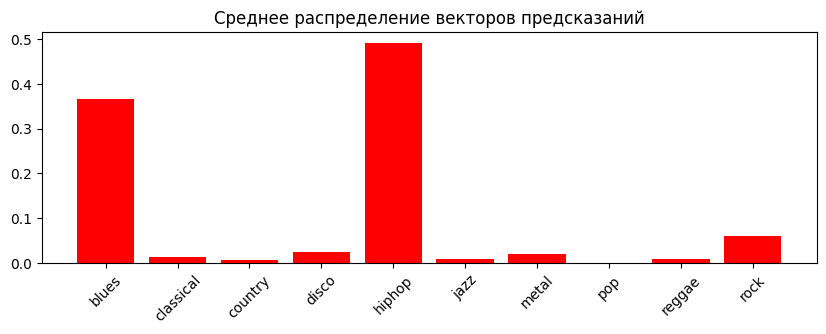

---------------------------------------------------------------
Файл: ./genres/disco/disco.00097.au
Вектор для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


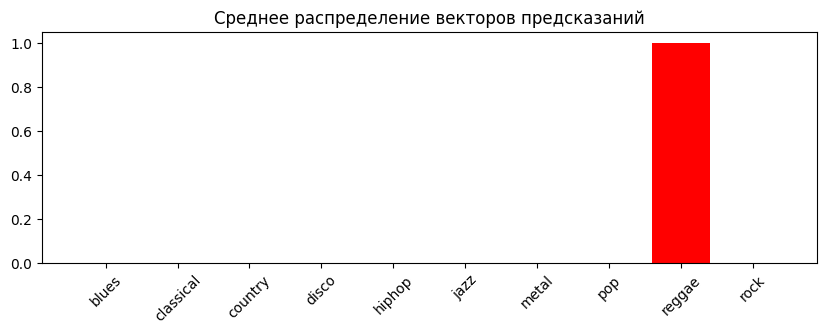

---------------------------------------------------------------
Файл: ./genres/disco/disco.00098.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


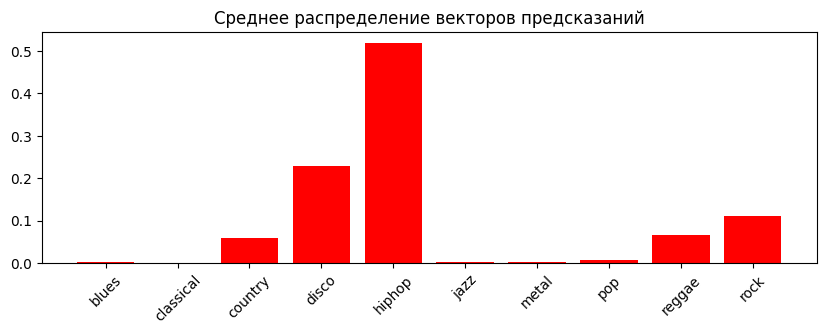

---------------------------------------------------------------
Файл: ./genres/disco/disco.00099.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


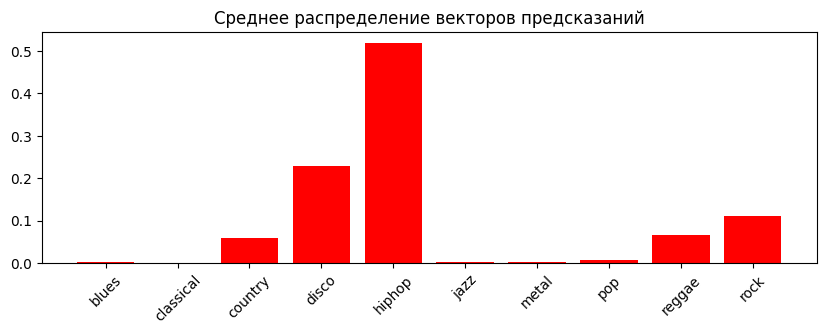

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00090.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - ВЕРНО :-)


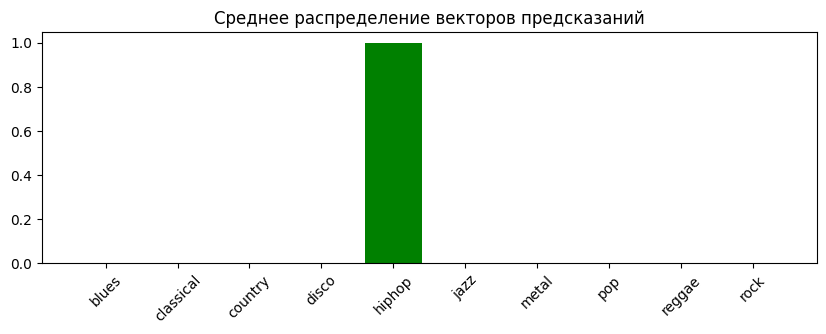

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00091.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - ВЕРНО :-)


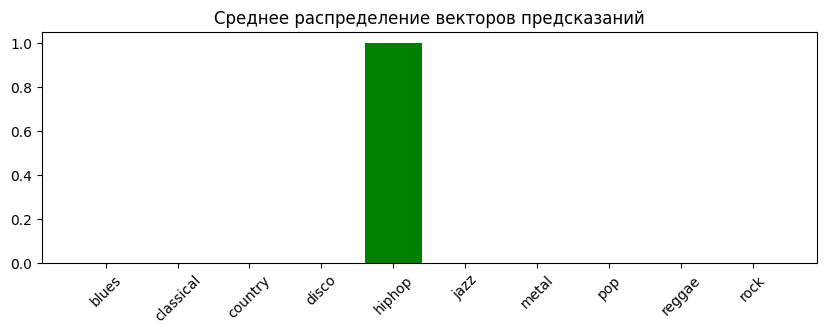

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00092.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - ВЕРНО :-)


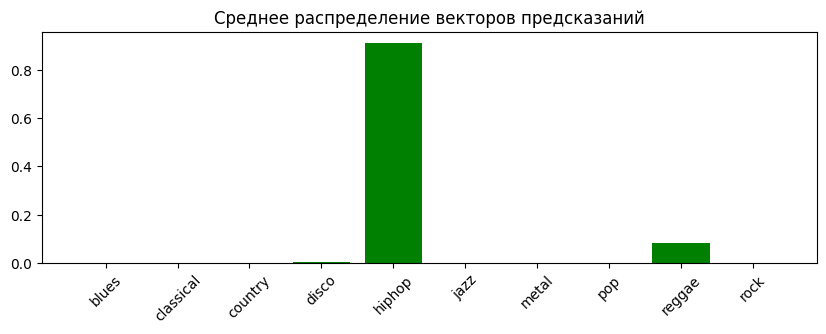

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00093.au
Вектор для предсказания: (1, 37)
Классификация сети: metal - НЕВЕРНО.


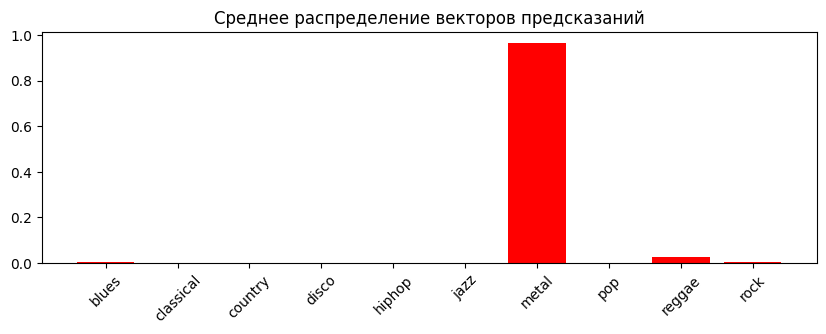

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00094.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - ВЕРНО :-)


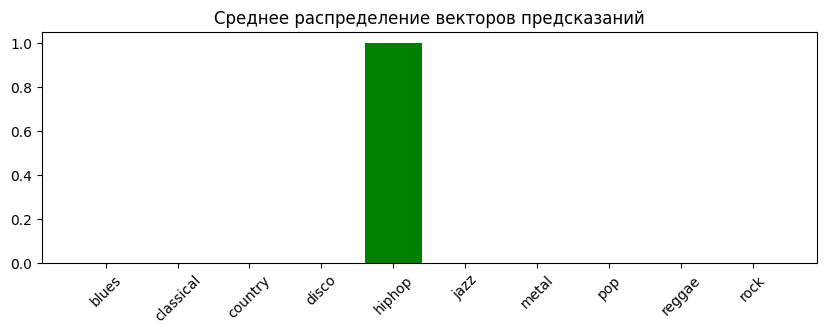

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00095.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - ВЕРНО :-)


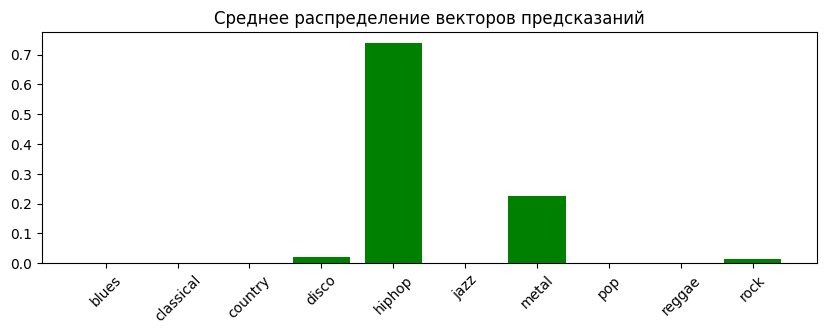

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00096.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - ВЕРНО :-)


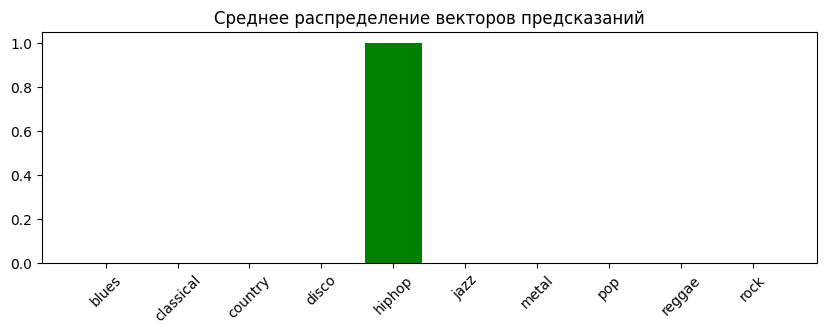

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00097.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - ВЕРНО :-)


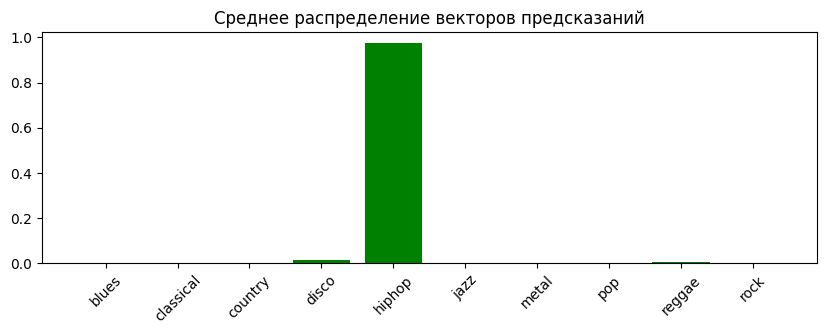

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00098.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - ВЕРНО :-)


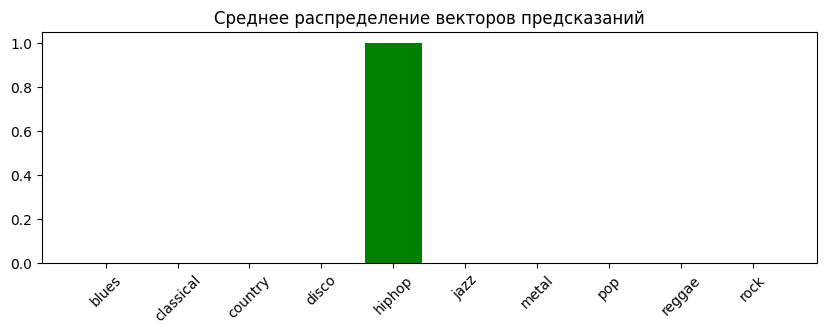

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00099.au
Вектор для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


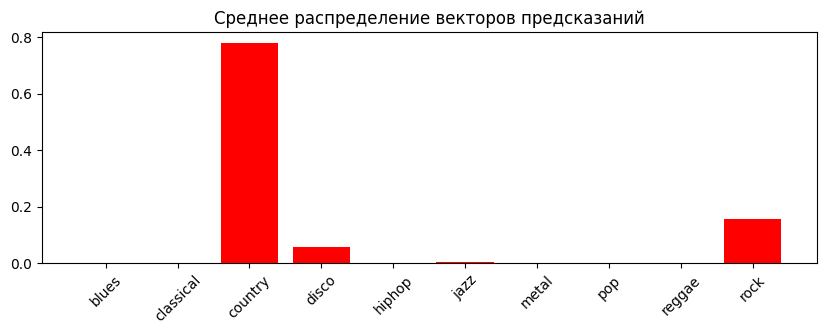

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00090.au
Вектор для предсказания: (1, 37)
Классификация сети: jazz - ВЕРНО :-)


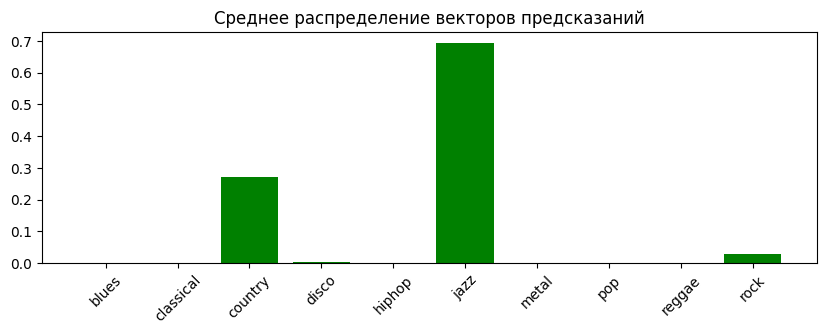

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00091.au
Вектор для предсказания: (1, 37)
Классификация сети: jazz - ВЕРНО :-)


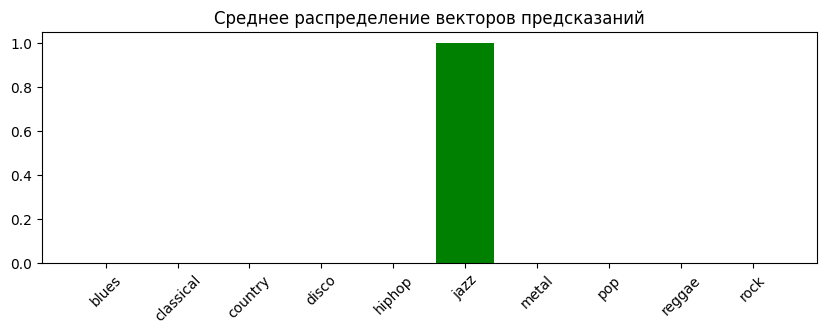

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00092.au
Вектор для предсказания: (1, 37)
Классификация сети: jazz - ВЕРНО :-)


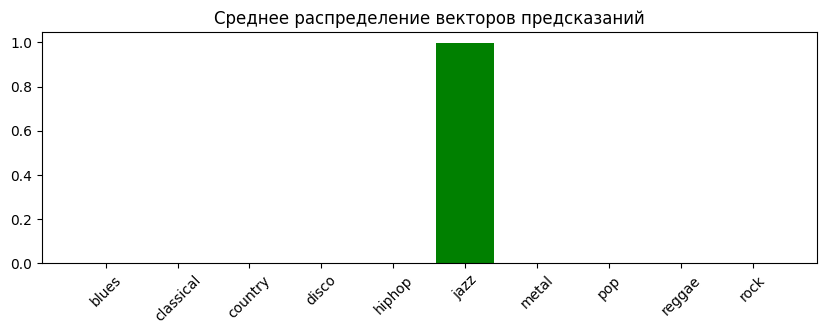

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00093.au
Вектор для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


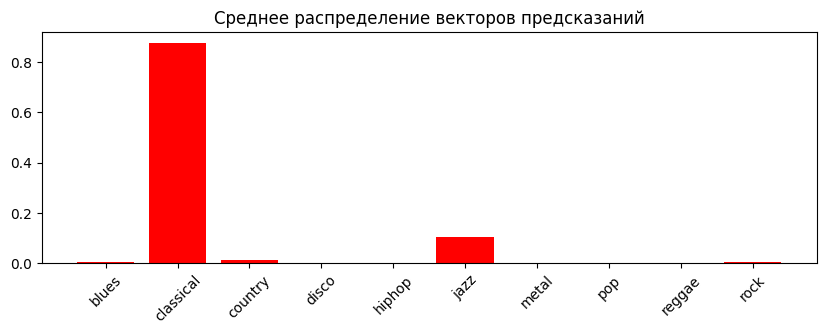

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00094.au
Вектор для предсказания: (1, 37)
Классификация сети: jazz - ВЕРНО :-)


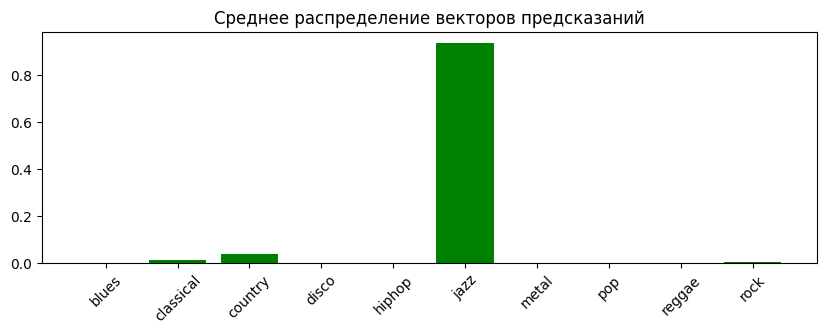

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00095.au
Вектор для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


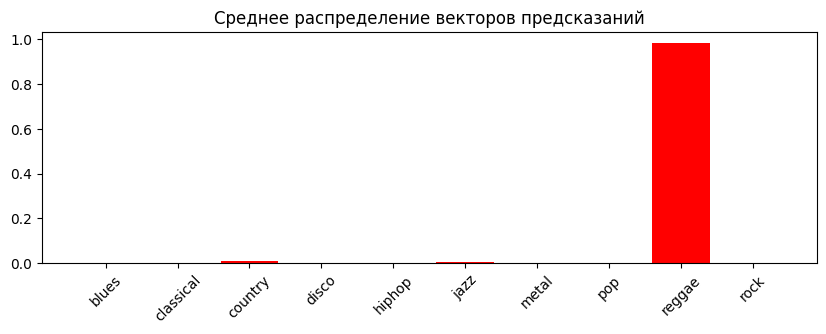

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00096.au
Вектор для предсказания: (1, 37)
Классификация сети: jazz - ВЕРНО :-)


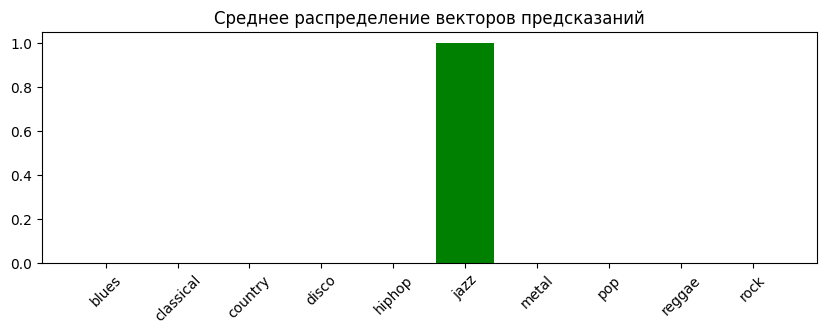

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00097.au
Вектор для предсказания: (1, 37)
Классификация сети: jazz - ВЕРНО :-)


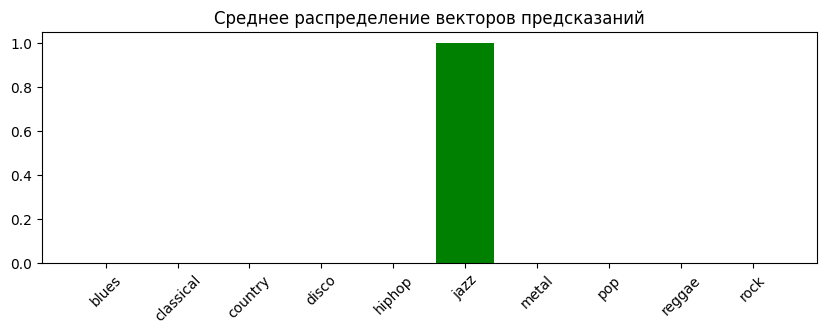

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00098.au
Вектор для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


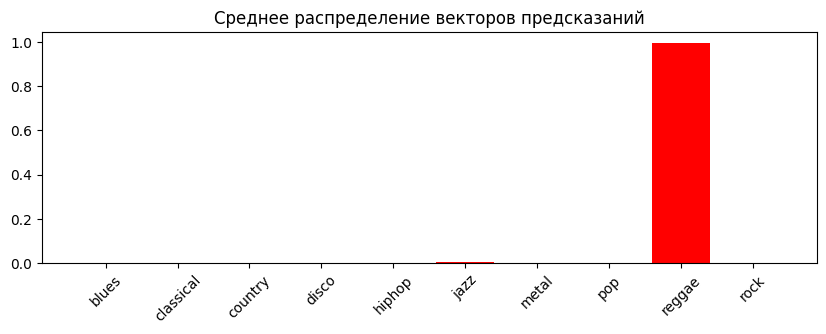

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00099.au
Вектор для предсказания: (1, 37)
Классификация сети: jazz - ВЕРНО :-)


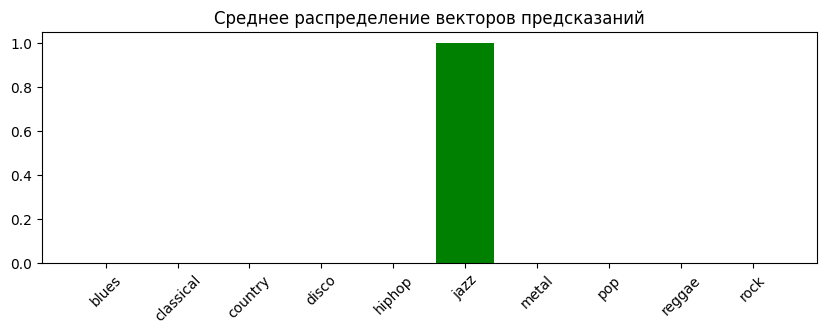

---------------------------------------------------------------
Файл: ./genres/metal/metal.00090.au
Вектор для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


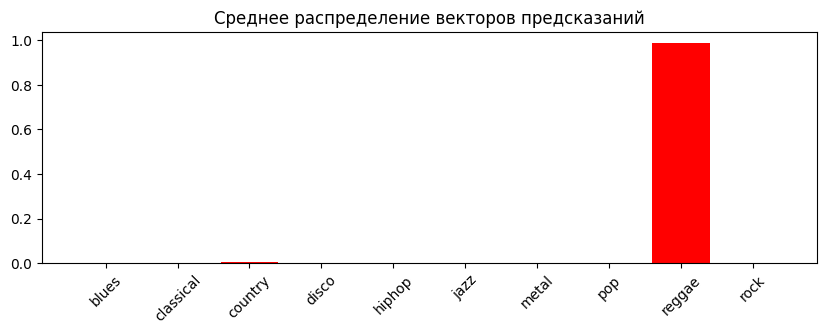

---------------------------------------------------------------
Файл: ./genres/metal/metal.00091.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


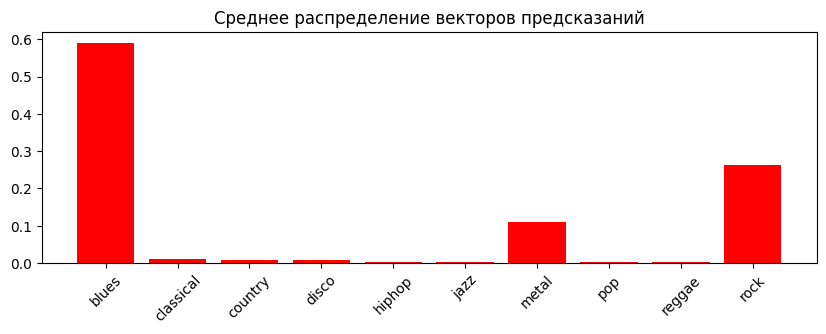

---------------------------------------------------------------
Файл: ./genres/metal/metal.00092.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


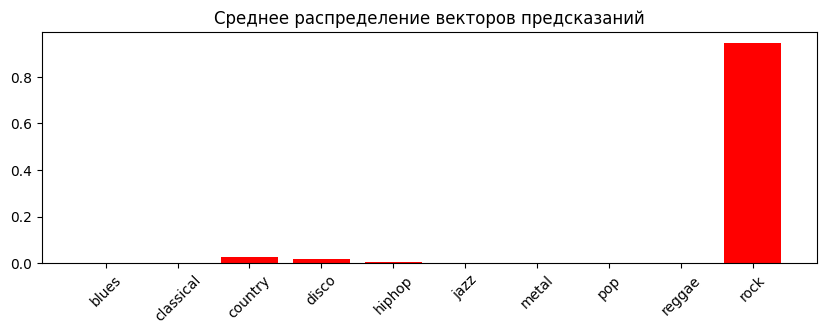

---------------------------------------------------------------
Файл: ./genres/metal/metal.00093.au
Вектор для предсказания: (1, 37)
Классификация сети: metal - ВЕРНО :-)


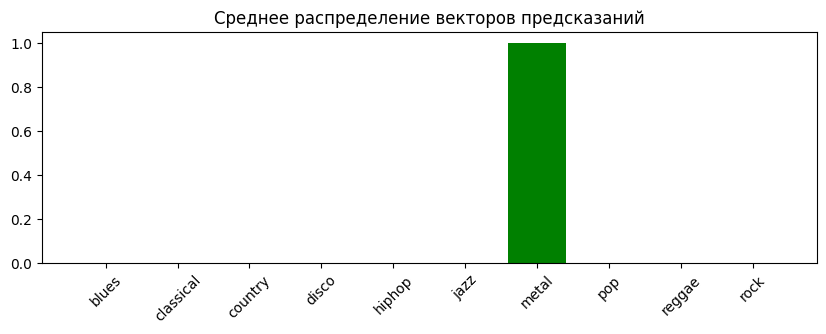

---------------------------------------------------------------
Файл: ./genres/metal/metal.00094.au
Вектор для предсказания: (1, 37)
Классификация сети: metal - ВЕРНО :-)


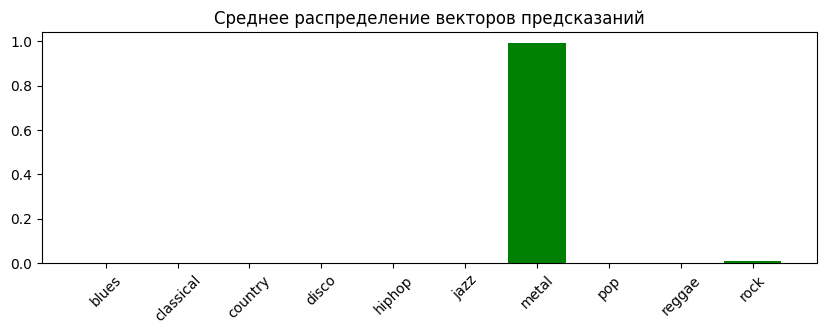

---------------------------------------------------------------
Файл: ./genres/metal/metal.00095.au
Вектор для предсказания: (1, 37)
Классификация сети: metal - ВЕРНО :-)


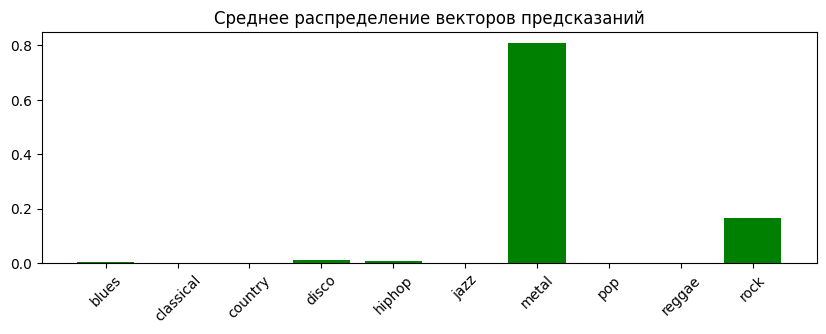

---------------------------------------------------------------
Файл: ./genres/metal/metal.00096.au
Вектор для предсказания: (1, 37)
Классификация сети: metal - ВЕРНО :-)


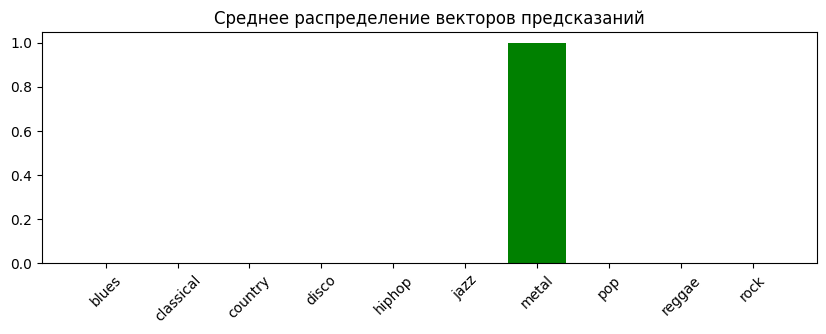

---------------------------------------------------------------
Файл: ./genres/metal/metal.00097.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


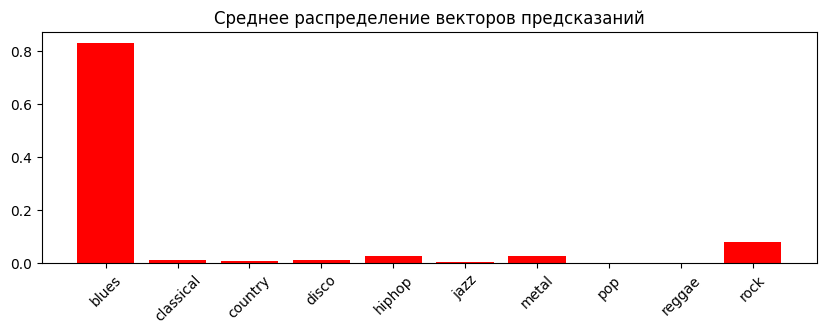

---------------------------------------------------------------
Файл: ./genres/metal/metal.00098.au
Вектор для предсказания: (1, 37)
Классификация сети: metal - ВЕРНО :-)


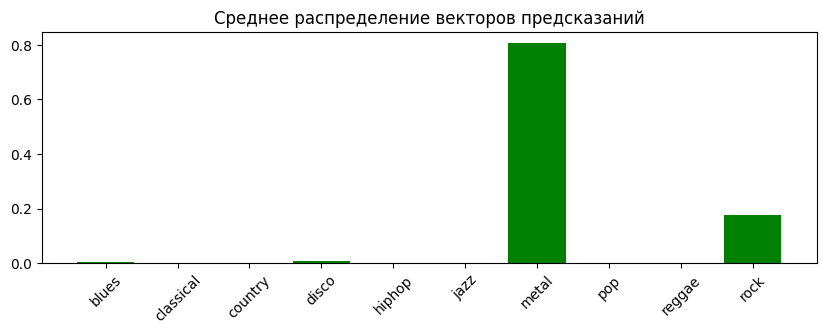

---------------------------------------------------------------
Файл: ./genres/metal/metal.00099.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


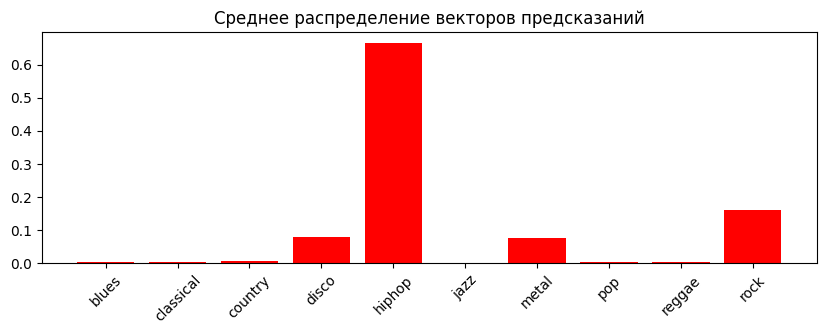

---------------------------------------------------------------
Файл: ./genres/pop/pop.00090.au
Вектор для предсказания: (1, 37)
Классификация сети: pop - ВЕРНО :-)


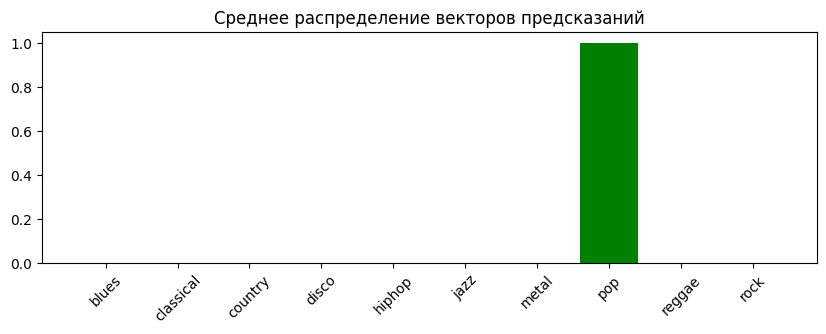

---------------------------------------------------------------
Файл: ./genres/pop/pop.00091.au
Вектор для предсказания: (1, 37)
Классификация сети: pop - ВЕРНО :-)


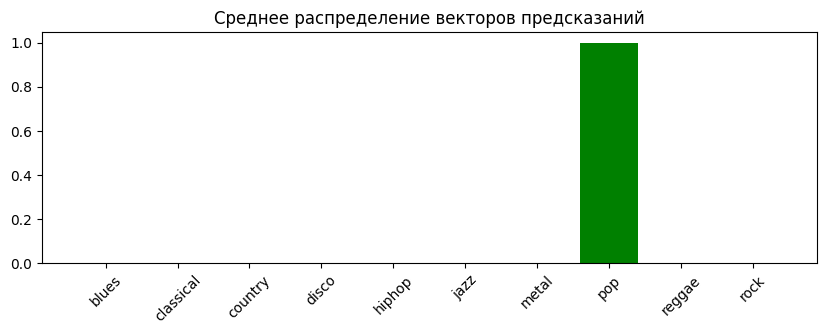

---------------------------------------------------------------
Файл: ./genres/pop/pop.00092.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


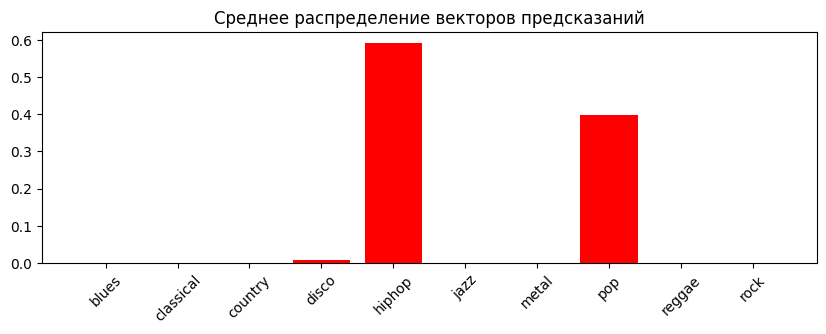

---------------------------------------------------------------
Файл: ./genres/pop/pop.00093.au
Вектор для предсказания: (1, 37)
Классификация сети: pop - ВЕРНО :-)


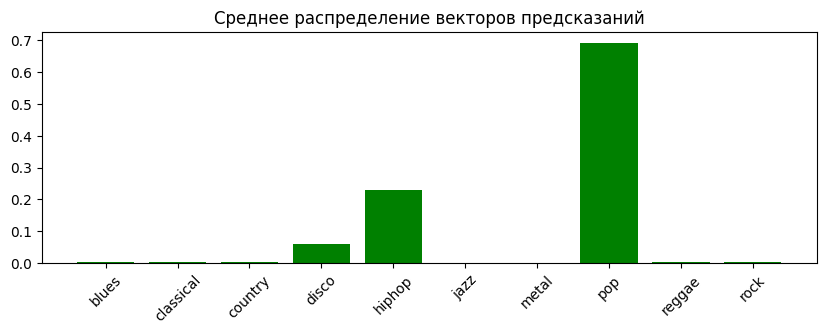

---------------------------------------------------------------
Файл: ./genres/pop/pop.00094.au
Вектор для предсказания: (1, 37)
Классификация сети: pop - ВЕРНО :-)


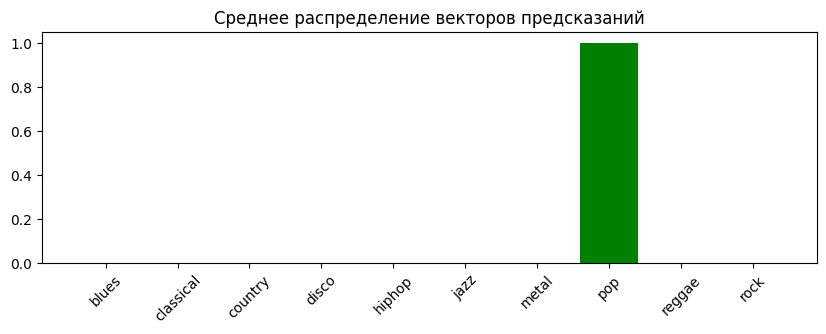

---------------------------------------------------------------
Файл: ./genres/pop/pop.00095.au
Вектор для предсказания: (1, 37)
Классификация сети: pop - ВЕРНО :-)


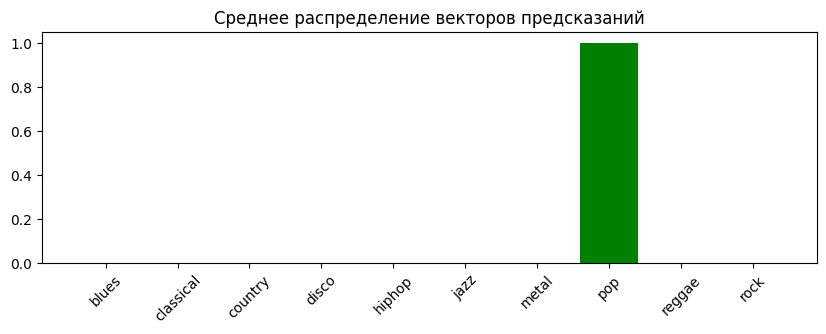

---------------------------------------------------------------
Файл: ./genres/pop/pop.00096.au
Вектор для предсказания: (1, 37)
Классификация сети: pop - ВЕРНО :-)


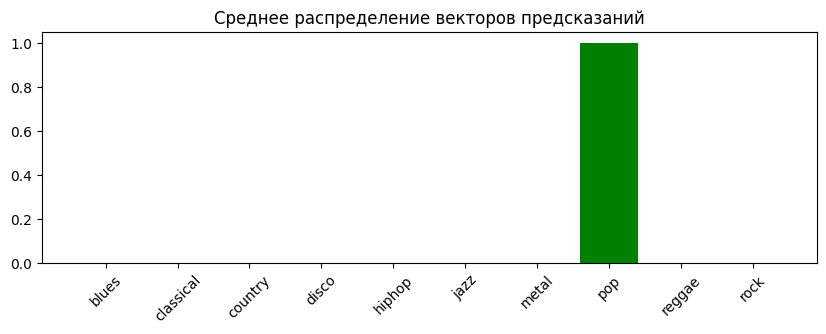

---------------------------------------------------------------
Файл: ./genres/pop/pop.00097.au
Вектор для предсказания: (1, 37)
Классификация сети: pop - ВЕРНО :-)


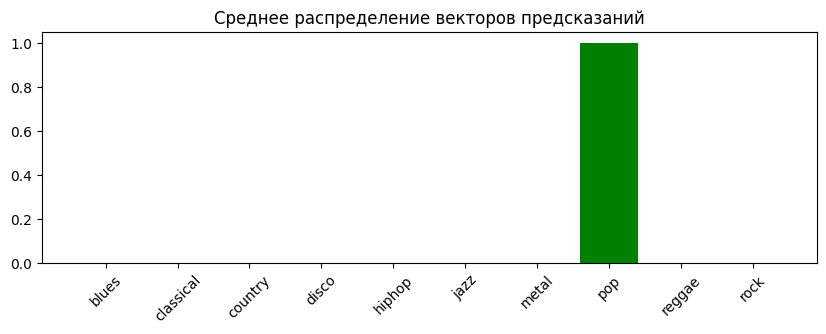

---------------------------------------------------------------
Файл: ./genres/pop/pop.00098.au
Вектор для предсказания: (1, 37)
Классификация сети: pop - ВЕРНО :-)


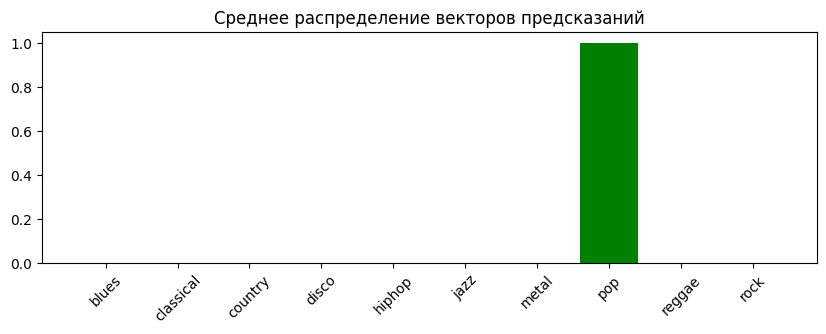

---------------------------------------------------------------
Файл: ./genres/pop/pop.00099.au
Вектор для предсказания: (1, 37)
Классификация сети: pop - ВЕРНО :-)


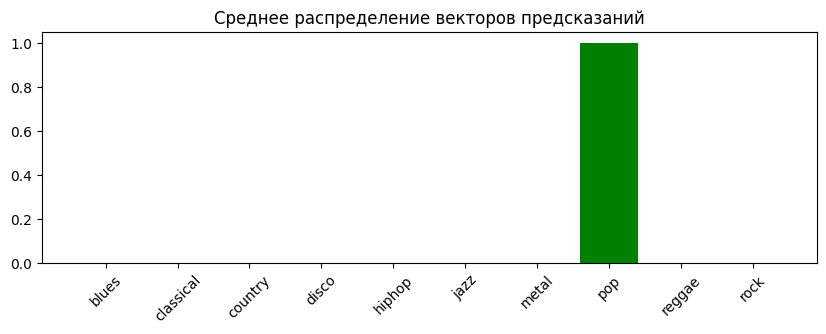

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00090.au
Вектор для предсказания: (1, 37)
Классификация сети: reggae - ВЕРНО :-)


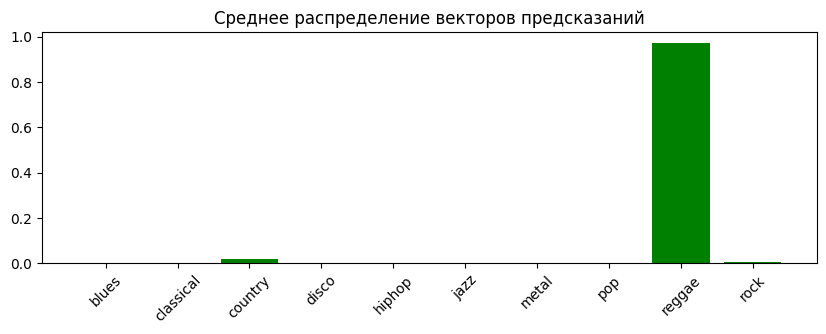

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00091.au
Вектор для предсказания: (1, 37)
Классификация сети: reggae - ВЕРНО :-)


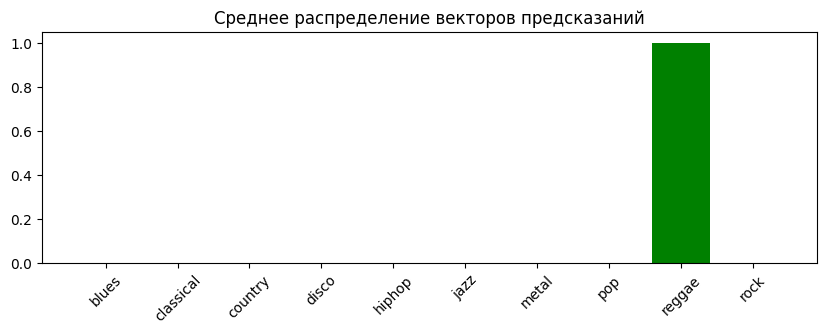

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00092.au
Вектор для предсказания: (1, 37)
Классификация сети: reggae - ВЕРНО :-)


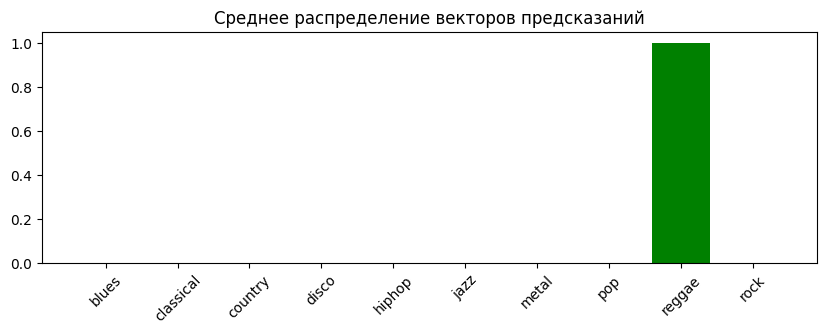

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00093.au
Вектор для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


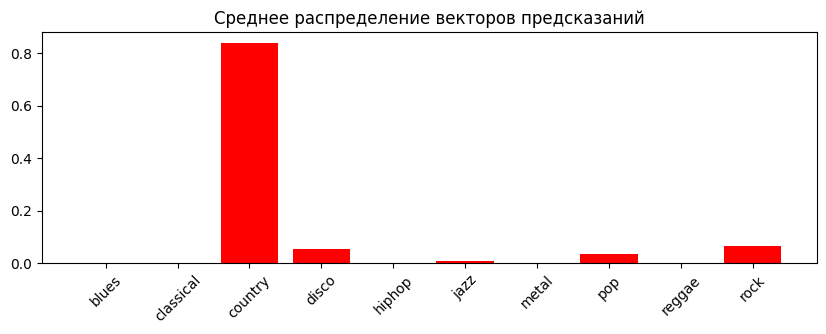

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00094.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


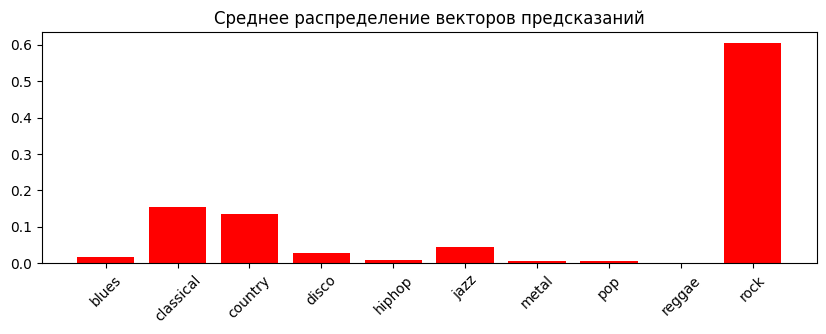

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00095.au
Вектор для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


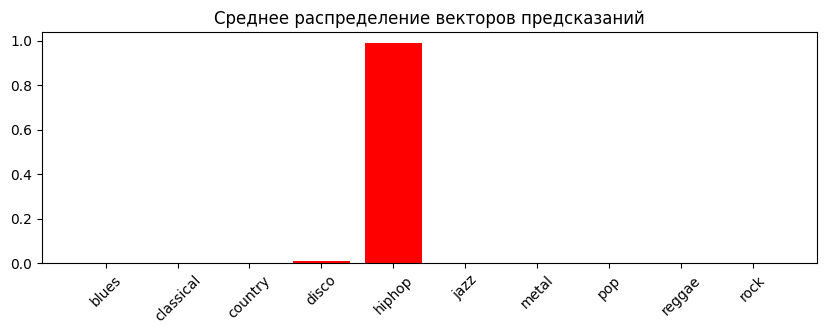

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00096.au
Вектор для предсказания: (1, 37)
Классификация сети: reggae - ВЕРНО :-)


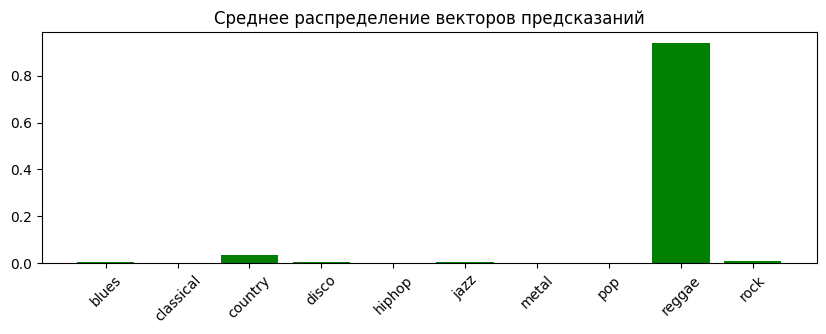

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00097.au
Вектор для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


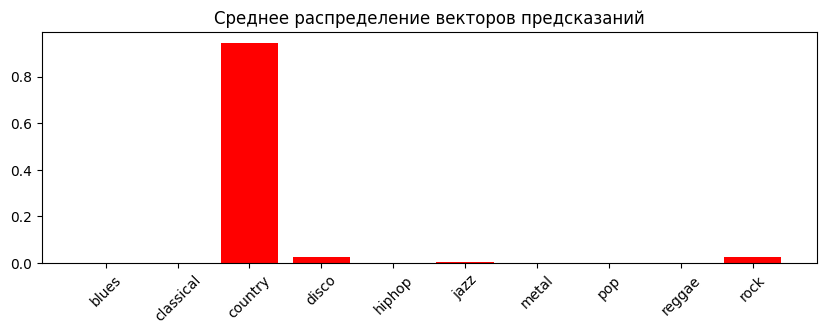

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00098.au
Вектор для предсказания: (1, 37)
Классификация сети: reggae - ВЕРНО :-)


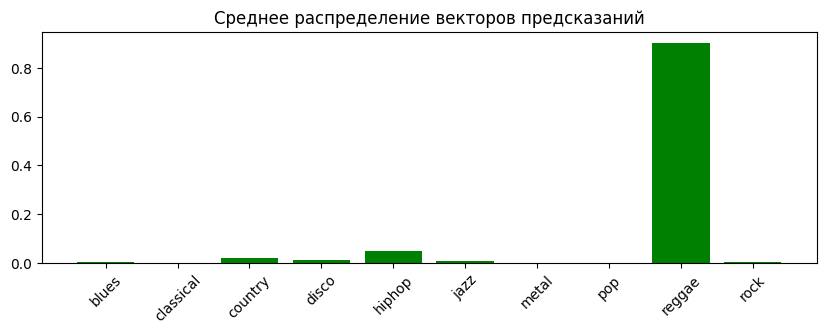

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00099.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


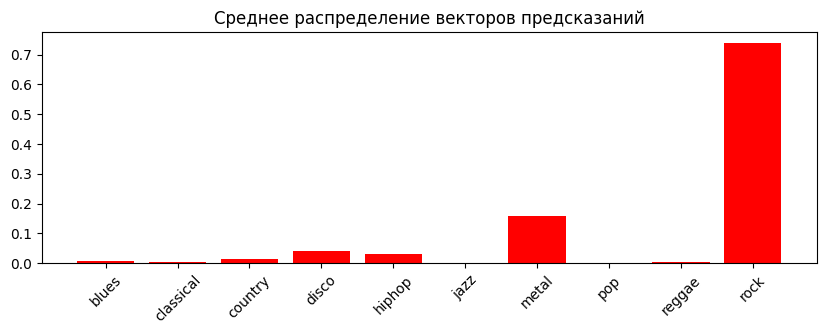

---------------------------------------------------------------
Файл: ./genres/rock/rock.00090.au
Вектор для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


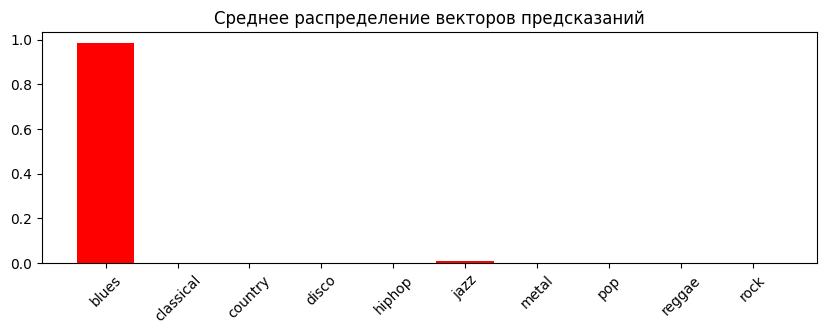

---------------------------------------------------------------
Файл: ./genres/rock/rock.00091.au
Вектор для предсказания: (1, 37)
Классификация сети: metal - НЕВЕРНО.


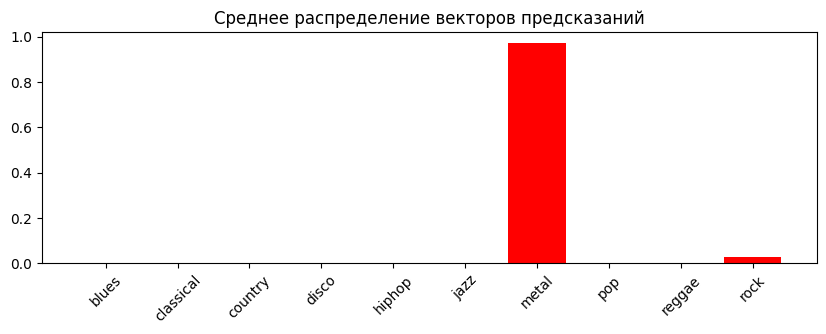

---------------------------------------------------------------
Файл: ./genres/rock/rock.00092.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - ВЕРНО :-)


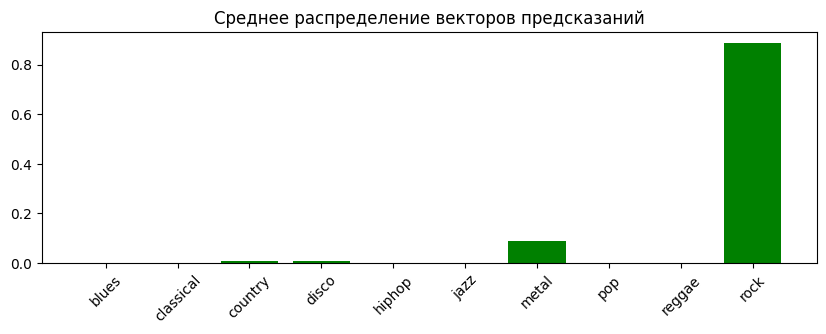

---------------------------------------------------------------
Файл: ./genres/rock/rock.00093.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - ВЕРНО :-)


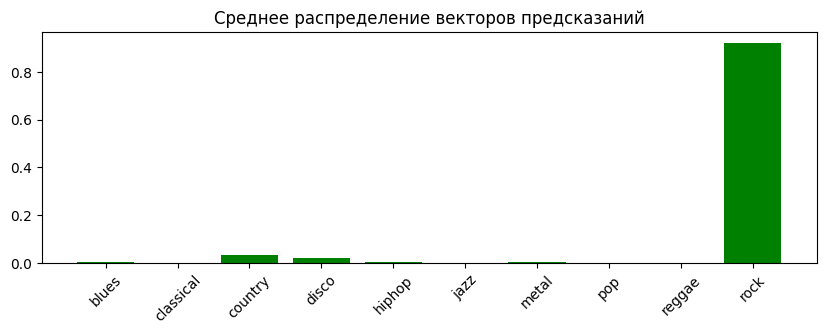

---------------------------------------------------------------
Файл: ./genres/rock/rock.00094.au
Вектор для предсказания: (1, 37)
Классификация сети: metal - НЕВЕРНО.


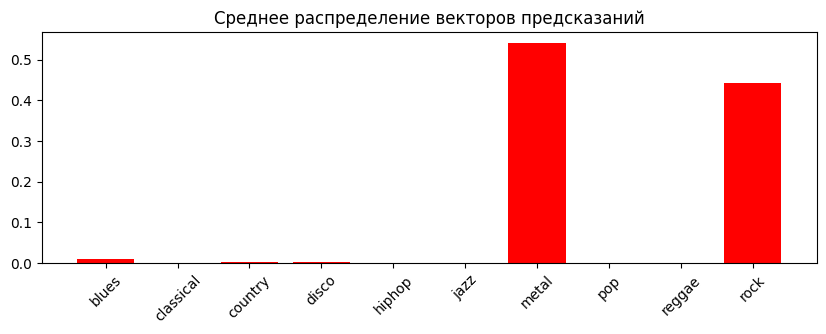

---------------------------------------------------------------
Файл: ./genres/rock/rock.00095.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - ВЕРНО :-)


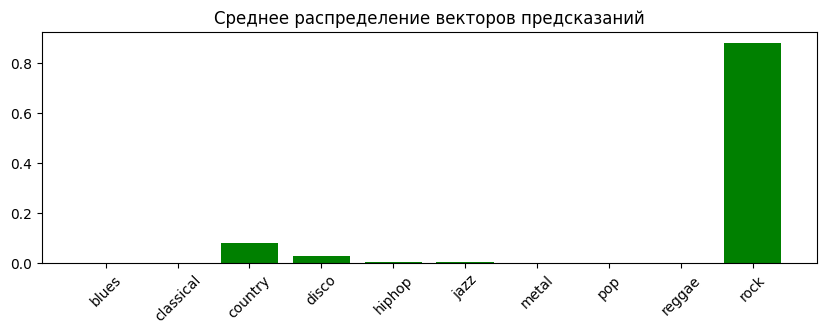

---------------------------------------------------------------
Файл: ./genres/rock/rock.00096.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - ВЕРНО :-)


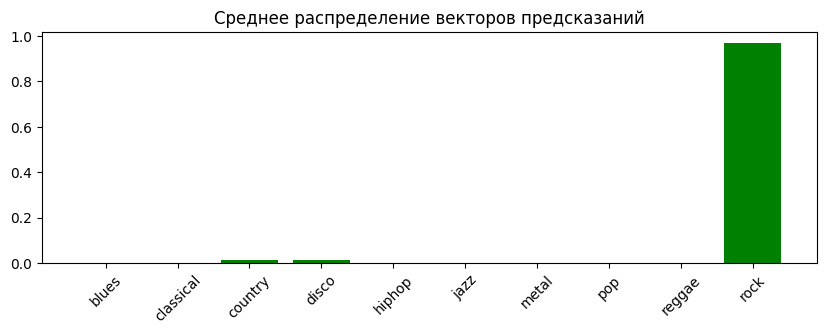

---------------------------------------------------------------
Файл: ./genres/rock/rock.00097.au
Вектор для предсказания: (1, 37)
Классификация сети: rock - ВЕРНО :-)


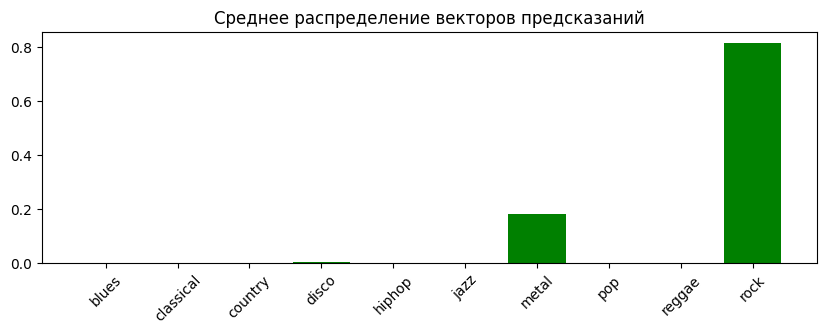

---------------------------------------------------------------
Файл: ./genres/rock/rock.00098.au
Вектор для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


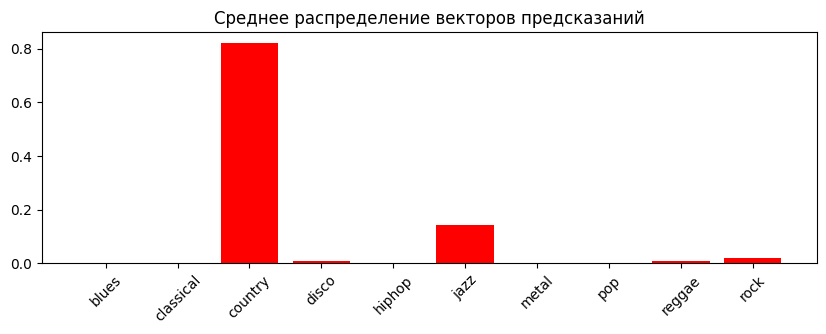

---------------------------------------------------------------
Файл: ./genres/rock/rock.00099.au
Вектор для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


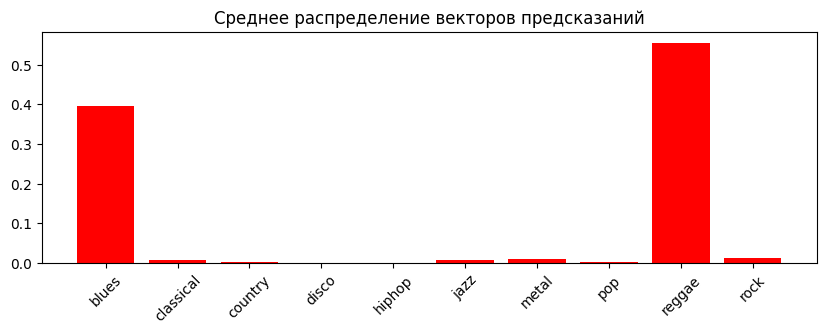

---------------------------------------------------------------
=== Обработано образцов: 100, из них распознано верно: 55, доля верных: 55.0% ===


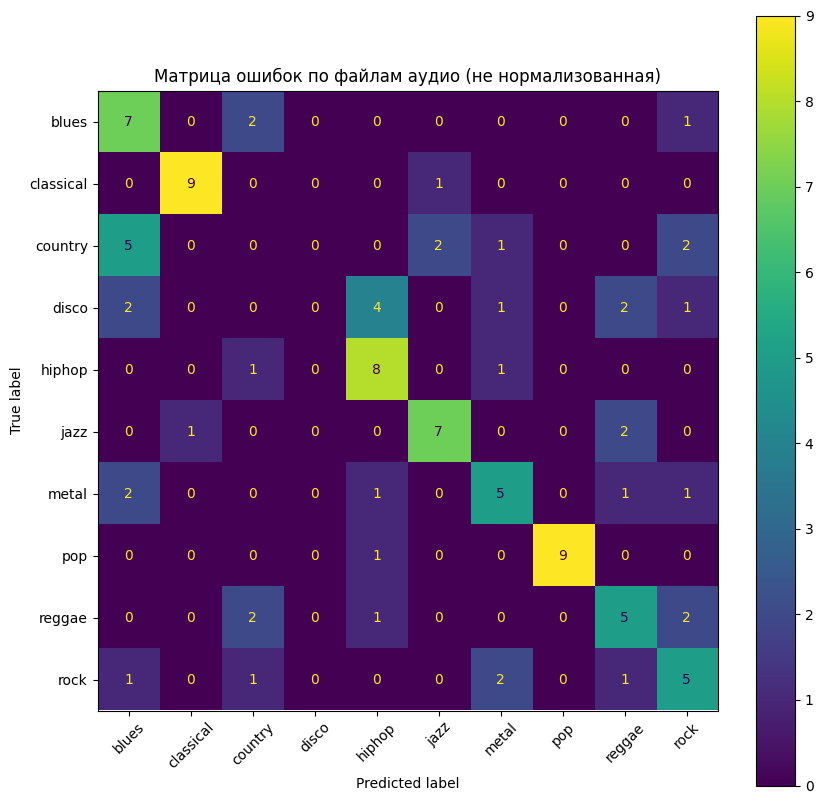

In [37]:
classify_test_files(model=model,
                    x_scaler=x_scaler,
                    from_index=90,
                    n_files=10)